# Feature Discovery — Structured Feature Search

**Phase 4a — `notebooks/02a-feature-discovery.ipynb`**

**Goal.** Discover new features that improve the model's ability to identify churners — specifically its PR-AUC, the primary selection metric for this project.

**Approach.** A baseline LightGBM trained on the raw IBM features already captures the dominant churn signals, but there may be additional structure the model cannot recover on its own. This notebook searches for that structure in two ways:

- **Error-driven (Laps 1–6):** profile the model's false negatives, identify subgroups it systematically misses, and hypothesise a feature that targets that blind spot directly.
- **Domain-derived (Laps 7–9):** hypothesise features based on domain knowledge of telecom pricing and service structure — row-level ratios and counts that require operations (division, within-row summation) no single tree split can replicate.

Both hypothesis sources are evaluated through the same four-screen gate. Every decision is logged so the adopted set is fully reproducible from the provenance record alone.

**The loop — one lap at a time:**
1. Identify the hypothesis source (FN blind spot or domain-derived structural gap)
2. Construct a candidate feature from columns available at serving time
3. Screen through four gates cheapest-first — adopt or reject

**Four-screen gate:**

| Screen | Name | Trigger for rejection |
|--------|------|------------------------|
| 1 | Serving availability | Any input column not computable from raw CSV columns at inference time |
| 2 | Redundancy | Structurally redundant with the already-adopted set |
| 3 | Performance | Global OOF PR-AUC improvement < 0.0015 (flat or regression) |
| 4 | Importance | Permutation importance ≤ random-noise decoy floor |

> **Screen 2 — redundancy (soft gate):** Spearman |r| for numeric candidates; Cramér's V for categorical — same-type only. Cross-type redundancy (e.g., a categorical encoding of a numeric column) is not caught; Screen 4 permutation importance is the backstop for that case. Screen 2 flags but does not auto-reject — evaluation always continues to Screen 3.

> **Screen 4 — negative decoy importance:** Expected — the model can mildly overfit to the random noise column; shuffling it then slightly improves performance. The effective floor clamps at zero: `max(noise, 0) + 0.005`, so a negative decoy never lowers the bar a candidate must clear.

**Outputs (written at the end):**
- `reports/feature_discovery/provenance.json` — per-lap trail (machine-readable)
- `reports/feature_discovery/provenance.md` — human-readable summary table
- `reports/feature_discovery/adopted_features.json` — frozen adopted-set list; input contract for `02b`


## Prerequisites

This notebook reads from the raw CSV — no database connection required.

Before running, ensure:
1. Dependencies are synced: `uv sync`
2. The raw dataset is present: `datasets/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv`

Run time: approximately 2–4 minutes (8 LightGBM 5-fold OOF fits on 7,043 rows).

In [ ]:
from __future__ import annotations

import json
import os
import warnings
from pathlib import Path

# nbconvert sets cwd to notebooks/; normalise to project root
if not Path("configs").exists():
    os.chdir("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import average_precision_score, confusion_matrix

from telco_churn.data.ingest import load_raw_csv
from telco_churn.data.validate import validate_raw
from telco_churn.features.generate import (
    CORR_THRESHOLD,
    CRAMERS_V_THRESHOLD,
    IMPORTANCE_NOISE_FLOOR_MARGIN,
    MIN_PR_AUC_DELTA,
    AdoptionDecision,
    LapRecord,
    adoption_gate,
    bootstrap_pr_auc_ci,
    candidate_importance,
    oof_predictions,
    profile_false_negatives,
    subgroup_recall,
    redundancy_screen,
    serving_available,
    write_provenance,
)
from telco_churn.features.preprocessing import build_preprocessor
from telco_churn.utils.paths import get_project_root, load_config

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42
DECOY_COL = "_decoy_noise"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

## 1. Base Feature Set — Raw IBM Columns Only

The discovery loop starts from the 19 raw IBM columns after ingest cleaning:
- 6 binary (5 Yes/No strings + `seniorcitizen` int 0/1)
- 10 multi-level categoricals
- 3 numeric (`tenure`, `monthlycharges`, `totalcharges`)

No engineered features are present yet. Every candidate introduced in the laps below is constructed
from scratch in this notebook; adopted candidates migrate to `build.py`.

In [ ]:
PROJECT_ROOT = get_project_root()
cfg = load_config()
raw_path = PROJECT_ROOT / cfg.paths.raw_data
df = load_raw_csv(raw_path)
validate_raw(df, strict=True)

BASE_BINARY = [
    "gender", "has_partner", "dependents", "phoneservice",
    "paperlessbilling", "seniorcitizen",
]
BASE_MULTI_CAT = [
    "multiplelines", "internetservice", "onlinesecurity", "onlinebackup",
    "deviceprotection", "techsupport", "streamingtv", "streamingmovies",
    "contract_type", "paymentmethod",
]
BASE_NUMERIC = ["tenure", "monthlycharges", "totalcharges"]

X_base = df[BASE_BINARY + BASE_MULTI_CAT + BASE_NUMERIC].copy()
y = df["churn"].copy()
DISCOVERY_THRESHOLD: float = round(float(y.mean()), 2)  # prevalence-based reference threshold for error profiling; not the production threshold
print(f"DISCOVERY_THRESHOLD : {DISCOVERY_THRESHOLD}  (churn prevalence; reference only — not the production threshold)")

# Persistent decoy noise column: same random state across all importance checks
decoy_col = pd.Series(
    np.random.default_rng(RANDOM_STATE).standard_normal(len(df)),
    index=df.index,
    name=DECOY_COL,
)

print(f"Dataset : {len(df):,} rows × {len(X_base.columns)} base feature columns")
print(f"Churn rate : {y.mean()*100:.1f}%  ({y.sum():,} positives)")
print(f"Gate constants: CORR_THRESHOLD={CORR_THRESHOLD}, "
      f"CRAMERS_V_THRESHOLD={CRAMERS_V_THRESHOLD}, "
      f"IMPORTANCE_NOISE_FLOOR_MARGIN={IMPORTANCE_NOISE_FLOOR_MARGIN}, "
      f"min_pr_auc_delta={MIN_PR_AUC_DELTA}")

DISCOVERY_THRESHOLD : 0.27  (churn prevalence; reference only — not the production threshold)
Dataset : 7,043 rows × 19 base feature columns
Churn rate : 26.5%  (1,869 positives)
Gate constants: CORR_THRESHOLD=0.85, CRAMERS_V_THRESHOLD=0.7, IMPORTANCE_NOISE_FLOOR_MARGIN=0.005, min_pr_auc_delta=0.0015


### Initialise discovery state

In [ ]:
# State bookkeeping — updated after every successful adoption

active_binary: list[str] = list(BASE_BINARY)
active_multi_cat: list[str] = list(BASE_MULTI_CAT)
active_numeric: list[str] = list(BASE_NUMERIC)

adopted_features: list[str] = []
adopted_df = X_base.copy()  # base columns always present; engineered features appended on adoption
lap_records: list[LapRecord] = []

print("Discovery state initialised.")
print(f"  Active binary    : {active_binary}")
print(f"  Active multi-cat : {active_multi_cat}")
print(f"  Active numeric   : {active_numeric}")


Discovery state initialised.
  Active binary    : ['gender', 'has_partner', 'dependents', 'phoneservice', 'paperlessbilling', 'seniorcitizen']
  Active multi-cat : ['multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract_type', 'paymentmethod']
  Active numeric   : ['tenure', 'monthlycharges', 'totalcharges']


## 2. Base Model: OOF Predictions

> **Prediction outcome terminology:**
> The model assigns each customer a churn probability (0–1); a threshold converts
> this into a binary decision. Four outcomes are possible:
>
> | | Model predicts: churns | Model predicts: stays |
> |---|---|---|
> | **Actually churns** | True Positive (TP) — caught | **False Negative (FN) — missed** |
> | **Actually stays** | False Positive (FP) — wasted call | True Negative (TN) — correctly ignored |
>
> **FNs are the costly error:** a missed churner loses lifetime value that cannot be
> recovered; a False Positive wastes one retention call — real but recoverable.
> This asymmetry drives the loop’s focus on subgroups with elevated FN rates
> (“blind spots”). Quantified cost structure and production threshold derivation: `ANALYSIS.md` §0.

A default LightGBM (untuned) is trained on the 19 raw IBM columns via 5-fold stratified
cross-validation. **Out-of-fold (OOF) probabilities** give every row a held-out score —
each fold scores only rows it never saw during training — keeping the error profile
leak-free without touching the sealed test set.

**Performance floor (PR-AUC bootstrap CI):** The primary metric sweeps all thresholds
and handles the 27% positive rate better than accuracy or F1. A 1,000-iteration bootstrap
CI on the base OOF PR-AUC sets the floor every candidate feature must clear (Screen 3).

**Decision threshold (`DISCOVERY_THRESHOLD`):** Set to the churn prevalence (~0.27)
rather than 0.5 — at 0.5 a model on a 27% minority class rarely predicts churn,
suppressing FN counts and obscuring blind spots. A reference value for lap-to-lap
comparisons only; the production threshold is derived from the business cost structure
after calibration.


### Fit base model and compute OOF probabilities

In [ ]:
preprocessor_base = build_preprocessor(
    binary=BASE_BINARY,
    multi_cat=BASE_MULTI_CAT,
    numeric=BASE_NUMERIC,
)

print("Computing base OOF predictions (5-fold, LightGBM) …")
base_oof_proba = oof_predictions(
    X_base, y, preprocessor_base, random_state=RANDOM_STATE
)
base_pr_auc = float(average_precision_score(y, base_oof_proba))
base_ci = bootstrap_pr_auc_ci(
    np.asarray(y), base_oof_proba, random_state=RANDOM_STATE
)

print(f"Base PR-AUC      : {base_pr_auc:.4f}")
print(f"Bootstrap 95% CI : [{base_ci[0]:.4f}, {base_ci[1]:.4f}]")

# Confusion matrix at the discovery threshold
y_pred_base = (base_oof_proba >= DISCOVERY_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y, y_pred_base).ravel()
print(f"\nConfusion matrix @ threshold={DISCOVERY_THRESHOLD} (prevalence-based reference)")
print(f"  True  Positives (caught churners)  : {tp:>5}")
print(f"  False Negatives (missed churners)  : {fn:>5}")
print(f"  False Positives (wasted calls)     : {fp:>5}")
print(f"  True  Negatives (correctly ignored): {tn:>5}")

# Wire base model into discovery state
current_oof_proba = base_oof_proba
current_pr_auc = base_pr_auc
current_ci = base_ci
X_current = X_base.copy()

print("\nBase model wired into discovery state.")


Computing base OOF predictions (5-fold, LightGBM) …


Base PR-AUC      : 0.6432
Bootstrap 95% CI : [0.6195, 0.6677]

Confusion matrix @ threshold=0.27 (prevalence-based reference)
  True  Positives (caught churners)  :  1633
  False Negatives (missed churners)  :   236
  False Positives (wasted calls)     :  1996
  True  Negatives (correctly ignored):  3178

Base model wired into discovery state.


## 3. Error-Driven Features

Laps 1–6 target the three blind spots flagged in the false-negative error profile below. For each subgroup the approach is
identical: inspect the within-subgroup distribution to form a hypothesis, construct a
binary candidate feature, and pass it through the four-screen adoption gate.

The three blind spots are interrogated in turn:

- Two-year contract customers (85.4 % FN rate, 48 missed churners) — highest FN rate
- One-year contract customers (54.2 % FN rate, 166 missed churners) — second-highest
- Tenure band (55–72 months) (53.7 % FN rate, 73 missed churners) — third-highest

### False-negative error profile

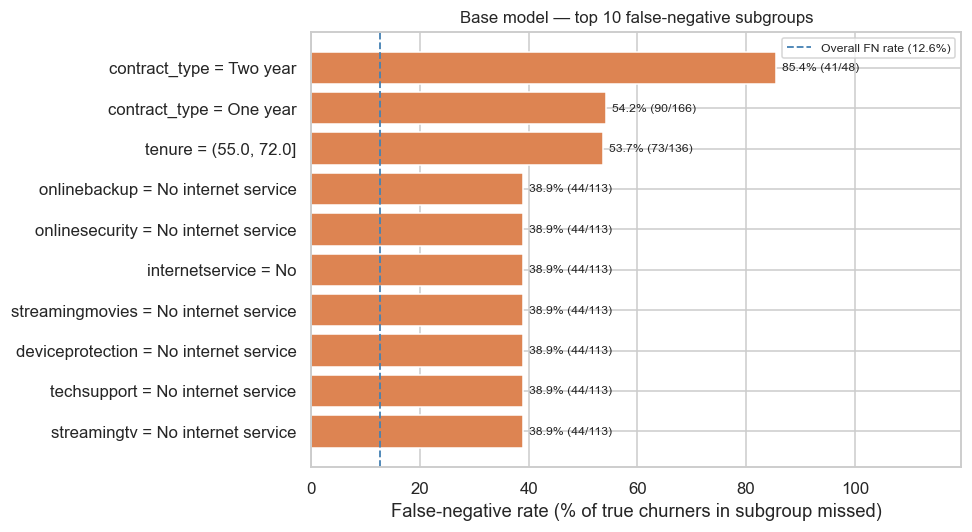

DISCOVERY_THRESHOLD        : 0.27
Total missed churners (FN) : 236
Total actual churners      : 1869
Overall FN rate            : 236 / 1869 = 0.126  (12.6%)


In [ ]:
# Show the top false-negative subgroups — these anchor each lap's hypothesis
base_fn = profile_false_negatives(X_base, y, base_oof_proba, threshold=DISCOVERY_THRESHOLD)

top_n = 10
plot_df = base_fn.head(top_n).copy()
labels = plot_df["feature"] + " = " + plot_df["subgroup"]

bar_labels = [
    f"{r*100:.1f}% ({int(c)}/{int(t)})"
    for r, c, t in zip(
        plot_df["fn_rate"][::-1],
        plot_df["fn_count"][::-1],
        plot_df["total_positives"][::-1],
    )
]

total_fn = int(((base_oof_proba < DISCOVERY_THRESHOLD) & (y == 1)).sum())
total_positives = int(y.sum())
overall_fn = total_fn / total_positives

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels[::-1], plot_df["fn_rate"][::-1] * 100, color="#DD8452")

ax.bar_label(bars, labels=bar_labels, padding=4, fontsize=8)
ax.axvline(overall_fn * 100, color="steelblue", linestyle="--", linewidth=1.2,
           label=f"Overall FN rate ({overall_fn*100:.1f}%)")
ax.set_xlim(0, plot_df["fn_rate"].max() * 140)
ax.set_title(f"Base model — top {top_n} false-negative subgroups", fontsize=11)
ax.set_xlabel("False-negative rate (% of true churners in subgroup missed)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"DISCOVERY_THRESHOLD        : {DISCOVERY_THRESHOLD}")
print(f"Total missed churners (FN) : {total_fn}")
print(f"Total actual churners      : {total_positives}")
print(f"Overall FN rate            : {total_fn} / {total_positives} = {overall_fn:.3f}  ({overall_fn*100:.1f}%)")

**Reading the chart:** The dashed line is the **overall FN rate** — the share of all true churners the base model misses at `DISCOVERY_THRESHOLD` (printed below the chart). Bar labels show the FN rate and count (`missed / total true churners in subgroup`). Any bar above the line marks a subgroup the model misses *worse* than average — these are the blind spots that anchor each lap's hypothesis.

These subgroup rates are treated as **hypotheses only** — scanning all feature × subgroup combinations constitutes multiple comparisons, so some elevated rates arise by chance. A candidate feature is adopted only if it improves OOF PR-AUC in the lap that follows.

**What the base model shows:**

- **`contract_type = Two year` (85.4%)** and **`contract_type = One Year` (54.2%)** dominate. Two-year and one-year customers rarely churn, and the model has learned this so strongly that it predicts “won’t churn” for nearly everyone in these groups — even customers who show other warning signs like high monthly charges. Since `contract_type` is already in the model, a new standalone feature won’t change this; what’s needed is an **interaction** that flags long-contract customers who *also* show a specific risk signal, giving the model a separate pattern to learn for that combination.

- **A `tenure` subgroup (~53.7%)** ranks third. The base model treats tenure as a raw continuous count and may underweight non-linear risk thresholds at specific tenure bands. Addressed in a subsequent lap.

- The remaining bars cluster near the overall FN rate, largely driven by no-internet-service subgroup combinations.

---
### Blind-spot deep-dive — two-year contract subgroup

Two-year customers have the highest FN rate (85.4%, 48 churners) in the base error
profile. Before forming a hypothesis, compare churners and non-churners **within this
subgroup** across every base feature. Note: with only 48 churners the proportions carry
more sampling noise than the overall dataset — interpret gaps directionally, not as
precise estimates.

In [ ]:
# Restrict to the two-year contract blind spot
two_year_mask = df["contract_type"] == "Two year"
grp   = df[two_year_mask].copy().reset_index(drop=True)
grp_y = y[two_year_mask].reset_index(drop=True)

n_c  = int(grp_y.sum())
n_nc = int((grp_y == 0).sum())
print(f"Two-year contract subgroup: {len(grp):,} customers  ({n_c} churners  |  {n_nc} non-churners)")
print()

# Numeric features: median by churn label; IQR as scale
num_rows = []
for col in BASE_NUMERIC:
    med_c  = grp.loc[grp_y == 1, col].median()
    med_nc = grp.loc[grp_y == 0, col].median()
    iqr    = grp[col].quantile(0.75) - grp[col].quantile(0.25)
    num_rows.append({
        "feature":     col,
        "churner":     round(med_c,  2),
        "non-churner": round(med_nc, 2),
        "Δ":           round(med_c - med_nc, 2),
        "Δ / IQR":     round((med_c - med_nc) / iqr, 3) if iqr > 0 else 0.0,
    })
num_df = (
    pd.DataFrame(num_rows)
    .sort_values("Δ / IQR", key=abs, ascending=False)
    .reset_index(drop=True)
)
print("Numeric features — median by churn label (sorted by effect size Δ/IQR):")
display(num_df)

# Categorical features: largest proportion gap across levels
cat_rows = []
for col in BASE_BINARY + BASE_MULTI_CAT:
    if col == "contract_type":
        continue
    ct = pd.crosstab(grp[col], grp_y)
    if 0 not in ct.columns or 1 not in ct.columns:
        continue
    ct_norm = ct.div(ct.sum(axis=0), axis=1)
    signed  = ct_norm[1] - ct_norm[0]
    top     = signed.idxmax()  # level most associated with churning
    cat_rows.append({
        "condition":        f"{col} = {top}",
        "churners w/ cond": f"{float(ct_norm.loc[top, 1]) * 100:.1f} %",
        "non-ch w/ cond":   f"{float(ct_norm.loc[top, 0]) * 100:.1f} %",
        "signed gap (pp)":    round(float(signed.loc[top]) * 100, 1),
        "direction":          "↑ churn" if signed.loc[top] > 0 else "↓ churn",
    })
cat_df = (
    pd.DataFrame(cat_rows)
    .sort_values("signed gap (pp)", ascending=False)
    .reset_index(drop=True)
)
print()
print("Categorical features — churner-direction gap per feature")
print("  ↑ churn = churners over-represented  →  interaction candidate")
print("  ↓ churn = non-churners over-represented  →  not a churn signal")
display(cat_df)

Two-year contract subgroup: 1,695 customers  (48 churners  |  1647 non-churners)

Numeric features — median by churn label (sorted by effect size Δ/IQR):


,feature,churner,non-churner,Δ,Δ / IQR
0,monthlycharges,97.28,63.3,33.98,0.511
1,totalcharges,5874.25,3527.0,2347.25,0.497
2,tenure,65.50,64.0,1.50,0.065



Categorical features — churner-direction gap per feature
  ↑ churn = churners over-represented  →  interaction candidate
  ↓ churn = non-churners over-represented  →  not a churn signal


,condition,churners w/ cond,non-ch w/ cond,signed gap (pp),direction
0,internetservice = Fiber optic,64.6 %,24.2 %,40.4,↑ churn
1,streamingtv = Yes,75.0 %,43.8 %,31.2,↑ churn
2,streamingmovies = Yes,70.8 %,44.4 %,26.4,↑ churn
3,onlinesecurity = No,43.8 %,17.5 %,26.2,↑ churn
4,deviceprotection = Yes,70.8 %,47.7 %,23.2,↑ churn
5,paperlessbilling = Yes,68.8 %,45.7 %,23.1,↑ churn
6,multiplelines = Yes,72.9 %,50.9 %,22.0,↑ churn
7,paymentmethod = Electronic check,27.1 %,9.4 %,17.7,↑ churn
8,onlinebackup = No,35.4 %,18.0 %,17.4,↑ churn
9,techsupport = No,29.2 %,13.5 %,15.7,↑ churn


**What the two-year data says.** Tenure is essentially flat (65.5 vs 64.0 months, Δ/IQR=0.065) — these are not recent sign-ups who regret locking in; they have been with the company as long as non-churners. The separation is entirely in *price and service mix*: churners pay a median $97.28/month vs $63.30 (+$33.98, Δ/IQR=0.511).

The signed-gap categorical table (churner % − non-churner %) shows every feature has at least one level over-represented in churners. The strongest signals, in rank order: `internetservice = Fiber optic` (+40.4 pp), `streamingtv = Yes` (+31.2 pp), `streamingmovies = Yes` (+26.4 pp), `onlinesecurity = No` (+26.2 pp), `deviceprotection = Yes` (+23.2 pp), `paperlessbilling = Yes` (+23.1 pp), `multiplelines = Yes` (+22.0 pp), and `paymentmethod = Electronic check` (+17.7 pp). The profile is consistent: two-year churners are heavy internet and streaming consumers, undersubscribed to security and support add-ons, and paying a premium per service.

### Diagnosis

**Mechanism: base-rate dominance.** Two-year customers churn at ~3% overall versus ~43% for month-to-month customers (§6c 01-eda.ipynb) — the model has learned this 40 pp gap as a dominant pattern, and raw price and service-mix signals get overridden within the subgroup because the contract-type prior is too strong.

**Fix type: targeted interaction.** Laps 1 and 2 test direct conjunctions of `contract_type = Two year` with the top two churner-direction signals from the two-year deep-dive: Fiber optic internet (+40.4 pp) and above-median monthly charges (+$33.98 median gap). Each binary flag gives the model an explicit probability bucket that it cannot recover from individual OHE columns alone.

**Structural caveat.** The two-year subgroup contains only 48 churners. Even a perfectly targeted interaction may produce a PR-AUC improvement too small to clear the MIN_PR_AUC_DELTA gate — the signal exists but the sample is too sparse for it to register globally. Laps 1 and 2 document what was tried; if both fail Screen 3, the blind spot is structural and the conclusion is that 48 churners is insufficient for feature-level recovery.

### LAP 1 — `two_year_fiber`

#### Blind spot
Two-year contract customers (48 churners, 85.4% FN rate) — the highest FN rate in the base error profile. The base-rate dominance diagnosis (see above) explains why a direct interaction targeting this subgroup is the logical first step.

#### Hypothesis
Within two-year customers, churners are on Fiber optic internet at 64.6% vs 24.2% of non-churners (+40.4 pp) — the single largest categorical gap in the two-year deep-dive. A binary flag `two_year_fiber = (contract_type = Two year) AND (internetservice = Fiber optic)` creates an explicit probability bucket isolating the highest-risk two-year cell without relying on the model to reconstruct this conjunction through consecutive axis-aligned splits.

#### EDA anchor
Two-year deep-dive: `internetservice = Fiber optic` +40.4 pp (64.6% churners vs 24.2% non-churners) — rank 1 churner-direction categorical gap in the subgroup.

#### Construct

In [ ]:
two_year_fiber = (
    (df["contract_type"] == "Two year")
    & (df["internetservice"] == "Fiber optic")
).astype(int).rename("two_year_fiber")

bs_pop_tyf        = (df["contract_type"] == "Two year") & (y == 1)
n_total           = len(df)
n_flagged         = int(two_year_fiber.sum())
n_ch_flag         = int(y[two_year_fiber == 1].sum())
n_two_year        = int((df["contract_type"] == "Two year").sum())
n_bs_ch           = int(bs_pop_tyf.sum())
n_bs_cap          = int((two_year_fiber[y == 1] == 1).sum())
two_year_rate     = float(y[df["contract_type"] == "Two year"].mean())
churn_rate_flag   = n_ch_flag / n_flagged

print(f"Two-year customers with Fiber optic  : {n_flagged:,} of {n_total:,}  ({two_year_fiber.mean() * 100:.1f}% of dataset)")
print(f"Churn rate — this group              : {churn_rate_flag * 100:.1f}%  ({n_ch_flag} of {n_flagged:,} churned)")
print(f"Churn rate — all two-year customers  : {two_year_rate * 100:.1f}%  ({n_bs_ch} of {n_two_year:,})")
print(f"Of the {n_bs_ch} two-year customers who churned : {n_bs_cap} are in this group  ({n_bs_cap / n_bs_ch * 100:.1f}%)")

Two-year customers with Fiber optic  : 429 of 7,043  (6.1% of dataset)
Churn rate — this group              : 7.2%  (31 of 429 churned)
Churn rate — all two-year customers  : 2.8%  (48 of 1,695)
Of the 48 two-year customers who churned : 31 are in this group  (64.6%)


#### Evaluate

In [ ]:
# Screen 1: source columns are contract_type and internetservice (both raw)
srv_tyf = serving_available(["contract_type", "internetservice"])
print(f"  Screen 1 (serving)    : {'PASS' if srv_tyf[0] else 'FAIL'}  {srv_tyf[1]}")

if not srv_tyf[0]:
    oof_tyf = current_oof_proba
    pr_auc_tyf = current_pr_auc
    ci_tyf = current_ci
    sub_delta_tyf = None
    imp_tyf = red_tyf = None
    decision_tyf = AdoptionDecision(adopted=False, rejection_screen=1, rejection_reason=srv_tyf[1])
else:
    red_tyf = redundancy_screen(two_year_fiber, adopted_df)
    print(f"  Screen 2 (redundancy) : {red_tyf.summary}")

    bs_mask_tyf = (df["contract_type"] == "Two year").values
    X_tyf = X_current.copy()
    X_tyf["two_year_fiber"] = two_year_fiber.values

    prep_tyf = build_preprocessor(
        binary=active_binary + ["two_year_fiber"],
        multi_cat=active_multi_cat,
        numeric=active_numeric,
    )

    oof_tyf    = oof_predictions(X_tyf, y, prep_tyf, random_state=RANDOM_STATE)
    pr_auc_tyf = float(average_precision_score(y, oof_tyf))
    ci_tyf     = bootstrap_pr_auc_ci(np.asarray(y), oof_tyf, random_state=RANDOM_STATE)
    delta_tyf  = pr_auc_tyf - current_pr_auc
    print(f"  Screen 3 (PR-AUC)     : {'PASS' if delta_tyf >= MIN_PR_AUC_DELTA else 'FAIL'}  "
          f"base={current_pr_auc:.4f}  new={pr_auc_tyf:.4f}  delta={delta_tyf:+.4f}  "
          f"min_delta={MIN_PR_AUC_DELTA}  CI=[{ci_tyf[0]:.4f}, {ci_tyf[1]:.4f}]")

    if delta_tyf < MIN_PR_AUC_DELTA:
        print("  Screen 4 (importance) : SKIPPED  (Screen 3 failed)")
        imp_tyf = None
        sub_delta_tyf = None
    else:
        X_imp_tyf = X_tyf.copy()
        X_imp_tyf[DECOY_COL] = decoy_col.values
        prep_imp_tyf = build_preprocessor(
            binary=active_binary + ["two_year_fiber"],
            multi_cat=active_multi_cat,
            numeric=active_numeric + [DECOY_COL],
        )
        imp_tyf = candidate_importance(
            X_imp_tyf, y, prep_imp_tyf, "two_year_fiber", DECOY_COL, random_state=RANDOM_STATE
        )
        print(f"  Screen 4 (importance) : {'PASS' if imp_tyf.above_floor else 'FAIL'}  "
              f"candidate={imp_tyf.candidate_importance:.4f}  floor={max(imp_tyf.noise_floor, 0.0) + IMPORTANCE_NOISE_FLOOR_MARGIN:.4f}  (noise={imp_tyf.noise_floor:.4f}, margin={IMPORTANCE_NOISE_FLOOR_MARGIN})")

        recall_base_tyf = subgroup_recall(current_oof_proba, y, bs_mask_tyf, threshold=DISCOVERY_THRESHOLD)
        recall_new_tyf  = subgroup_recall(oof_tyf, y, bs_mask_tyf, threshold=DISCOVERY_THRESHOLD)
        sub_delta_tyf   = recall_new_tyf - recall_base_tyf
        print(f"  blind-spot FN rate    : {1 - recall_base_tyf:.3f} -> {1 - recall_new_tyf:.3f}  "
              f"(delta={sub_delta_tyf:+.4f})  [diagnostic]")

    decision_tyf = adoption_gate(
        serving_result=srv_tyf,
        redundancy_result=red_tyf,
        prior_pr_auc=current_pr_auc,
        new_pr_auc=pr_auc_tyf,
        sub_recall_delta=sub_delta_tyf,
        importance_result=imp_tyf,
    )

print(f"  DECISION              : {'ADOPT' if decision_tyf.adopted else 'REJECT'}")
if decision_tyf.rejection_screen:
    print(f"  Rejected at Screen    : {decision_tyf.rejection_screen}  ({decision_tyf.rejection_reason})")


  Screen 1 (serving)    : PASS  all input columns available at serving time
  Screen 2 (redundancy) : PASS  max_corr=0.383 (threshold=0.85)


  Screen 3 (PR-AUC)     : PASS  base=0.6432  new=0.6479  delta=+0.0047  min_delta=0.0015  CI=[0.6248, 0.6723]


  Screen 4 (importance) : FAIL  candidate=0.0000  floor=0.0050  (noise=-0.0072, margin=0.005)
  blind-spot FN rate    : 0.854 -> 0.854  (delta=+0.0000)  [diagnostic]
  DECISION              : REJECT
  Rejected at Screen    : 4  (importance 0.0000 ≤ effective floor 0.0050 (noise=-0.0072, margin=0.005))


#### Record

In [ ]:
lap_records.append(LapRecord(
    lap=1,
    blind_spot="two-year contract customers (contract_type = Two year)",
    candidate="two_year_fiber",
    hypothesis=(
        "Within two-year customers, churners have Fiber optic internet at 64.6% vs 24.2% "
        "(+40.4 pp) — the highest churner-direction categorical gap in the two-year deep-dive. "
        "A binary flag encoding the conjunction creates an explicit probability bucket "
        "that the model cannot recover from individual OHE columns through consecutive splits."
    ),
    eda_anchor=(
        "Two-year deep-dive: internetservice=Fiber optic +40.4 pp "
        "(64.6% churners vs 24.2% non-churners) — rank 1 churner-direction categorical gap."
    ),
    max_corr=red_tyf.max_corr if red_tyf is not None else None,
    max_cramers_v=red_tyf.max_cramers_v if red_tyf is not None else None,
    prior_pr_auc=current_pr_auc,
    new_pr_auc=pr_auc_tyf,
    delta_pr_auc=pr_auc_tyf - current_pr_auc,
    prior_ci_low=current_ci[0],
    prior_ci_high=current_ci[1],
    sub_recall_delta=sub_delta_tyf,
    candidate_importance_score=imp_tyf.candidate_importance if imp_tyf is not None else 0.0,
    noise_floor=imp_tyf.noise_floor if imp_tyf is not None else 0.0,
    decision="adopt" if decision_tyf.adopted else "reject",
    rejection_screen=decision_tyf.rejection_screen,
    rejection_reason=decision_tyf.rejection_reason,
))

if decision_tyf.adopted:
    active_binary = active_binary + ["two_year_fiber"]
    adopted_features.append("two_year_fiber")
    adopted_df["two_year_fiber"] = two_year_fiber.values
    X_current = X_tyf.copy()
    current_oof_proba = oof_tyf
    current_pr_auc = pr_auc_tyf
    current_ci = ci_tyf
    print("ADOPTED  two_year_fiber")
    print(f"  active_binary   : {active_binary}")
    print(f"  adopted_features: {adopted_features}")
else:
    print("REJECTED  two_year_fiber -- state unchanged")

REJECTED  two_year_fiber -- state unchanged


**Lap 1 result — REJECTED at Screen 4.**

`two_year_fiber` (contract_type = Two year AND internetservice = Fiber optic) flags 429 customers (6.1% of the dataset) with a churn rate of 7.2% — 2.5× the two-year average of 2.8%. It covers 31 of the 48 two-year churners (64.6%), confirming the hypothesis is directionally sound.

Screens 1–3 passed: the feature is servable, non-redundant, and nudged the model's ranking score upward (+0.0047 PR-AUC). Screen 4 failed: when we tested whether the model actually uses this feature, removing it had zero effect on predictions — meaning it adds complexity without contributing signal. The root cause is sparsity: with only 48 two-year churners (2.8% of the subgroup), there is too little training signal for the model to learn from this interaction.

### LAP 2 — `two_year_high_charge`

#### Blind spot
Two-year contract customers (48 churners, 85.4% FN rate). Lap 1 targeted the Fiber optic signal. Lap 2 targets the price dimension: within the subgroup, churners pay a median $97.28/month vs $63.30 for non-churners (+$33.98, Δ/IQR=0.511) — the second-ranked separator in the two-year deep-dive.

#### Hypothesis
Two-year churners systematically pay above the global monthly-charge median while non-churners cluster below it. A binary flag `two_year_high_charge = (contract_type = Two year) AND (monthlycharges > global median)` creates an explicit high-cost two-year bucket, directly encoding the price signal that the base model fails to exploit within this loyalty-prior-dominated subgroup.

#### EDA anchor
Two-year deep-dive: `monthlycharges` Δ/IQR=0.511 ($97.28 churners vs $63.30 non-churners, +$33.98 gap) — largest numeric separator in the subgroup.

#### Construct

In [ ]:
mc_global_median = df["monthlycharges"].median()

two_year_high_charge = (
    (df["contract_type"] == "Two year")
    & (df["monthlycharges"] > mc_global_median)
).astype(int).rename("two_year_high_charge")

bs_pop_tyhc        = (df["contract_type"] == "Two year") & (y == 1)
n_total           = len(df)
n_flagged         = int(two_year_high_charge.sum())
n_ch_flag         = int(y[two_year_high_charge == 1].sum())
n_two_year        = int((df["contract_type"] == "Two year").sum())
n_bs_ch           = int(bs_pop_tyhc.sum())
n_bs_cap          = int((two_year_high_charge[y == 1] == 1).sum())
two_year_rate     = float(y[df["contract_type"] == "Two year"].mean())
churn_rate_flag   = n_ch_flag / n_flagged

print(f"Global monthlycharges median : ${mc_global_median:.2f}")
print(f"Two-year customers with above-median monthly charges  : {n_flagged:,} of {n_total:,}  ({two_year_high_charge.mean() * 100:.1f}% of dataset)")
print(f"Churn rate — this group              : {churn_rate_flag * 100:.1f}%  ({n_ch_flag} of {n_flagged:,} churned)")
print(f"Churn rate — all two-year customers  : {two_year_rate * 100:.1f}%  ({n_bs_ch} of {n_two_year:,})")
print(f"Of the {n_bs_ch} two-year customers who churned : {n_bs_cap} are in this group  ({n_bs_cap / n_bs_ch * 100:.1f}%)")

Global monthlycharges median : $70.35
Two-year customers with above-median monthly charges  : 764 of 7,043  (10.8% of dataset)
Churn rate — this group              : 4.7%  (36 of 764 churned)
Churn rate — all two-year customers  : 2.8%  (48 of 1,695)
Of the 48 two-year customers who churned : 36 are in this group  (75.0%)


#### Evaluate

In [ ]:
# Screen 1: source columns are contract_type and monthlycharges (both raw)
srv_tyhc = serving_available(["contract_type", "monthlycharges"])
print(f"  Screen 1 (serving)    : {'PASS' if srv_tyhc[0] else 'FAIL'}  {srv_tyhc[1]}")

if not srv_tyhc[0]:
    oof_tyhc = current_oof_proba
    pr_auc_tyhc = current_pr_auc
    ci_tyhc = current_ci
    sub_delta_tyhc = None
    imp_tyhc = red_tyhc = None
    decision_tyhc = AdoptionDecision(adopted=False, rejection_screen=1, rejection_reason=srv_tyhc[1])
else:
    red_tyhc = redundancy_screen(two_year_high_charge, adopted_df)
    print(f"  Screen 2 (redundancy) : {red_tyhc.summary}")

    bs_mask_tyhc = (df["contract_type"] == "Two year").values
    X_tyhc = X_current.copy()
    X_tyhc["two_year_high_charge"] = two_year_high_charge.values

    prep_tyhc = build_preprocessor(
        binary=active_binary + ["two_year_high_charge"],
        multi_cat=active_multi_cat,
        numeric=active_numeric,
    )

    oof_tyhc    = oof_predictions(X_tyhc, y, prep_tyhc, random_state=RANDOM_STATE)
    pr_auc_tyhc = float(average_precision_score(y, oof_tyhc))
    ci_tyhc     = bootstrap_pr_auc_ci(np.asarray(y), oof_tyhc, random_state=RANDOM_STATE)
    delta_tyhc  = pr_auc_tyhc - current_pr_auc
    print(f"  Screen 3 (PR-AUC)     : {'PASS' if delta_tyhc >= MIN_PR_AUC_DELTA else 'FAIL'}  "
          f"base={current_pr_auc:.4f}  new={pr_auc_tyhc:.4f}  delta={delta_tyhc:+.4f}  "
          f"min_delta={MIN_PR_AUC_DELTA}  CI=[{ci_tyhc[0]:.4f}, {ci_tyhc[1]:.4f}]")

    if delta_tyhc < MIN_PR_AUC_DELTA:
        print("  Screen 4 (importance) : SKIPPED  (Screen 3 failed)")
        imp_tyhc = None
        sub_delta_tyhc = None
    else:
        X_imp_tyhc = X_tyhc.copy()
        X_imp_tyhc[DECOY_COL] = decoy_col.values
        prep_imp_tyhc = build_preprocessor(
            binary=active_binary + ["two_year_high_charge"],
            multi_cat=active_multi_cat,
            numeric=active_numeric + [DECOY_COL],
        )
        imp_tyhc = candidate_importance(
            X_imp_tyhc, y, prep_imp_tyhc, "two_year_high_charge", DECOY_COL, random_state=RANDOM_STATE
        )
        print(f"  Screen 4 (importance) : {'PASS' if imp_tyhc.above_floor else 'FAIL'}  "
              f"candidate={imp_tyhc.candidate_importance:.4f}  floor={max(imp_tyhc.noise_floor, 0.0) + IMPORTANCE_NOISE_FLOOR_MARGIN:.4f}  (noise={imp_tyhc.noise_floor:.4f}, margin={IMPORTANCE_NOISE_FLOOR_MARGIN})")

        recall_base_tyhc = subgroup_recall(current_oof_proba, y, bs_mask_tyhc, threshold=DISCOVERY_THRESHOLD)
        recall_new_tyhc  = subgroup_recall(oof_tyhc, y, bs_mask_tyhc, threshold=DISCOVERY_THRESHOLD)
        sub_delta_tyhc   = recall_new_tyhc - recall_base_tyhc
        print(f"  blind-spot FN rate    : {1 - recall_base_tyhc:.3f} -> {1 - recall_new_tyhc:.3f}  "
              f"(delta={sub_delta_tyhc:+.4f})  [diagnostic]")

    decision_tyhc = adoption_gate(
        serving_result=srv_tyhc,
        redundancy_result=red_tyhc,
        prior_pr_auc=current_pr_auc,
        new_pr_auc=pr_auc_tyhc,
        sub_recall_delta=sub_delta_tyhc,
        importance_result=imp_tyhc,
    )

print(f"  DECISION              : {'ADOPT' if decision_tyhc.adopted else 'REJECT'}")
if decision_tyhc.rejection_screen:
    print(f"  Rejected at Screen    : {decision_tyhc.rejection_screen}  ({decision_tyhc.rejection_reason})")


  Screen 1 (serving)    : PASS  all input columns available at serving time
  Screen 2 (redundancy) : PASS  max_corr=0.475 (threshold=0.85)


  Screen 3 (PR-AUC)     : FAIL  base=0.6432  new=0.6424  delta=-0.0008  min_delta=0.0015  CI=[0.6179, 0.6672]
  Screen 4 (importance) : SKIPPED  (Screen 3 failed)
  DECISION              : REJECT
  Rejected at Screen    : 3  (PR-AUC delta -0.0008 below minimum 0.0015 (prior=0.6432, new=0.6424))


#### Record

In [ ]:
lap_records.append(LapRecord(
    lap=2,
    blind_spot="two-year contract customers (contract_type = Two year)",
    candidate="two_year_high_charge",
    hypothesis=(
        "Two-year churners pay a median $97.28/month vs $63.30 for non-churners (+$33.98). "
        "A binary flag encoding contract_type=Two year AND monthlycharges > global median "
        "creates an explicit high-cost two-year bucket, directly conditioning on the "
        "price signal the base model suppresses under the loyalty prior."
    ),
    eda_anchor=(
        "Two-year deep-dive: monthlycharges Δ/IQR=0.511 "
        "($97.28 churners vs $63.30 non-churners, +$33.98 gap) — "
        "largest numeric separator in the subgroup."
    ),
    max_corr=red_tyhc.max_corr if red_tyhc is not None else None,
    max_cramers_v=red_tyhc.max_cramers_v if red_tyhc is not None else None,
    prior_pr_auc=current_pr_auc,
    new_pr_auc=pr_auc_tyhc,
    delta_pr_auc=pr_auc_tyhc - current_pr_auc,
    prior_ci_low=current_ci[0],
    prior_ci_high=current_ci[1],
    sub_recall_delta=sub_delta_tyhc,
    candidate_importance_score=imp_tyhc.candidate_importance if imp_tyhc is not None else 0.0,
    noise_floor=imp_tyhc.noise_floor if imp_tyhc is not None else 0.0,
    decision="adopt" if decision_tyhc.adopted else "reject",
    rejection_screen=decision_tyhc.rejection_screen,
    rejection_reason=decision_tyhc.rejection_reason,
))

if decision_tyhc.adopted:
    active_binary = active_binary + ["two_year_high_charge"]
    adopted_features.append("two_year_high_charge")
    adopted_df["two_year_high_charge"] = two_year_high_charge.values
    X_current = X_tyhc.copy()
    current_oof_proba = oof_tyhc
    current_pr_auc = pr_auc_tyhc
    current_ci = ci_tyhc
    print("ADOPTED  two_year_high_charge")
    print(f"  active_binary   : {active_binary}")
    print(f"  adopted_features: {adopted_features}")
else:
    print("REJECTED  two_year_high_charge -- state unchanged")

REJECTED  two_year_high_charge -- state unchanged


**Lap 2 result — REJECTED at Screen 3.**

`two_year_high_charge` (contract_type = Two year AND monthlycharges > $70.35, the dataset median) flags 764 customers (10.8% of the dataset) with a churn rate of 4.7% — 1.7× the two-year average of 2.8%. It captures 36 of the 48 two-year churners (75.0%), stronger coverage than LAP 1.

Screens 1 and 2 passed: the feature is servable and non-redundant. Screen 3 failed: rather than improving how well the model ranks churners above non-churners, this feature made it marginally worse (−0.0008 PR-AUC). The root cause is that monthly charges are already an input the model sees in full — a simple “above or below median” cut is a cruder version of the same information, and the model has no reason to prefer it. Strong subgroup coverage did not help when the feature carried nothing new.


### Two-year segment — structural conclusion

Two laps, two rejections for different reasons. Lap 1 (`two_year_fiber`) correctly identified a high-risk cell — 64.6% of two-year churners covered, churn rate 2.5× the two-year average — but the model never used the flag: it already sees `contract_type` and `internetservice` as separate inputs and can work out their combination on its own. Lap 2 (`two_year_high_charge`) improved coverage to 75% but hurt the model's ranking score (−0.0008): a blunt above/below-median cut carries less information than the raw price column the model already reads directly.

Two forces are at work here. First, with only 48 churners in this segment, there is too little data for the model to learn reliably from a narrow interaction flag — the signal is too sparse. Second, and more fundamentally, the model already sees the individual columns that make up each flag; flagging their combination adds nothing it cannot already learn on its own. The one-year laps (166 churners) later confirm this second point holds even with adequate data. We close the two-year loop and move on.

---
### Blind-spot deep-dive — one-year contract subgroup

One-year customers have the second-highest FN rate (54.2%) in the base error profile, with
166 churners at an 11.3% base rate — 3.5× more positive examples than the two-year segment
(48 churners, 2.8%). That sample mass gives targeted interactions a real chance of clearing
the gates where two-year laps could not. Before forming a hypothesis, compare churners and
non-churners **within this subgroup** across every base feature. Interpret proportion gaps
directionally — the subgroup is still a minority of the dataset, so some gaps carry sampling noise.

In [ ]:
# Restrict to the one-year contract blind spot
one_year_mask = df["contract_type"] == "One year"
grp_1y   = df[one_year_mask].copy().reset_index(drop=True)
grp_1y_y = y[one_year_mask].reset_index(drop=True)

n_c_1y  = int(grp_1y_y.sum())
n_nc_1y = int((grp_1y_y == 0).sum())
print(f"One-year contract subgroup: {len(grp_1y):,} customers  ({n_c_1y} churners  |  {n_nc_1y} non-churners)")
print()

# Numeric features: median by churn label; IQR as scale
num_rows_1y = []
for col in BASE_NUMERIC:
    med_c  = grp_1y.loc[grp_1y_y == 1, col].median()
    med_nc = grp_1y.loc[grp_1y_y == 0, col].median()
    iqr    = grp_1y[col].quantile(0.75) - grp_1y[col].quantile(0.25)
    num_rows_1y.append({
        "feature":     col,
        "churner":     round(med_c,  2),
        "non-churner": round(med_nc, 2),
        "Δ":           round(med_c - med_nc, 2),
        "Δ / IQR":     round((med_c - med_nc) / iqr, 3) if iqr > 0 else 0.0,
    })
num_df_1y = (
    pd.DataFrame(num_rows_1y)
    .sort_values("Δ / IQR", key=abs, ascending=False)
    .reset_index(drop=True)
)
print("Numeric features — median by churn label (sorted by effect size Δ/IQR):")
display(num_df_1y)

# Categorical features: largest proportion gap across levels
cat_rows_1y = []
for col in BASE_BINARY + BASE_MULTI_CAT:
    if col == "contract_type":
        continue
    ct = pd.crosstab(grp_1y[col], grp_1y_y)
    if 0 not in ct.columns or 1 not in ct.columns:
        continue
    ct_norm = ct.div(ct.sum(axis=0), axis=1)
    signed  = ct_norm[1] - ct_norm[0]
    top     = signed.idxmax()
    cat_rows_1y.append({
        "condition":        f"{col} = {top}",
        "churners w/ cond": f"{float(ct_norm.loc[top, 1]) * 100:.1f} %",
        "non-ch w/ cond":   f"{float(ct_norm.loc[top, 0]) * 100:.1f} %",
        "signed gap (pp)":    round(float(signed.loc[top]) * 100, 1),
        "direction":          "↑ churn" if signed.loc[top] > 0 else "↓ churn",
    })
cat_df_1y = (
    pd.DataFrame(cat_rows_1y)
    .sort_values("signed gap (pp)", ascending=False)
    .reset_index(drop=True)
)
print()
print("Categorical features — churner-direction gap per feature")
print("  ↑ churn = churners over-represented  →  interaction candidate")
print("  ↓ churn = non-churners over-represented  →  not a churn signal")
display(cat_df_1y)

One-year contract subgroup: 1,473 customers  (166 churners  |  1307 non-churners)

Numeric features — median by churn label (sorted by effect size Δ/IQR):


,feature,churner,non-churner,Δ,Δ / IQR
0,monthlycharges,95.05,64.85,30.20,0.445
1,totalcharges,4098.52,2477.30,1621.22,0.419
2,tenure,48.00,43.00,5.00,0.161



Categorical features — churner-direction gap per feature
  ↑ churn = churners over-represented  →  interaction candidate
  ↓ churn = non-churners over-represented  →  not a churn signal


,condition,churners w/ cond,non-ch w/ cond,signed gap (pp),direction
0,streamingmovies = Yes,77.1 %,40.9 %,36.3,↑ churn
1,streamingtv = Yes,72.9 %,40.6 %,32.3,↑ churn
2,internetservice = Fiber optic,62.7 %,33.3 %,29.4,↑ churn
3,onlinesecurity = No,58.4 %,35.2 %,23.2,↑ churn
4,paperlessbilling = Yes,71.1 %,52.2 %,18.9,↑ churn
5,paymentmethod = Electronic check,38.6 %,21.7 %,16.9,↑ churn
6,multiplelines = Yes,56.0 %,40.0 %,16.0,↑ churn
7,onlinebackup = Yes,55.4 %,40.6 %,14.9,↑ churn
8,deviceprotection = Yes,56.6 %,42.2 %,14.4,↑ churn
9,techsupport = No,49.4 %,36.3 %,13.1,↑ churn


**What the one-year data says.** Tenure shows a small but real separation (48.0 vs 43.0 months, Δ/IQR=0.161) — churners have been with the company somewhat longer, consistent with a gradual accumulation of services before eventually churning. This contrasts with the two-year subgroup where tenure was essentially zero (Δ/IQR=0.065); here it is weak but not negligible. The dominant separation is still in price and service mix: churners pay a median $95.05/month vs $64.85 (+$30.20, Δ/IQR=0.445).

The signed-gap categorical table tells a clearer story than two-year did. The strongest signals in rank order: `streamingmovies = Yes` (+36.3 pp), `streamingtv = Yes` (+32.3 pp), `internetservice = Fiber optic` (+29.4 pp), `onlinesecurity = No` (+23.2 pp), `paperlessbilling = Yes` (+18.9 pp), `paymentmethod = Electronic check` (+16.9 pp). The profile is a heavy media-and-connectivity consumer — streaming subscriptions, Fiber optic, multiple lines, device protection — who has *not* subscribed to the security and support add-ons that increase switching costs. Two signals worth noting: `onlinebackup = Yes` is over-represented among churners (+14.9 pp), not `= No` as in two-year, suggesting the one-year churner profile is additive-service-heavy rather than security-light; and `techsupport = No` (+13.1 pp) reinforces the low-stickiness-service pattern.

### Diagnosis

**Mechanism: base-rate dominance, better odds than two-year.** One-year customers churn at ~11.3% vs ~43% for month-to-month — the model's loyalty prior suppresses predictions here for the same reason as two-year. The 32 pp gap is narrower than two-year's 40 pp gap, and 166 positive examples give targeted interactions a realistic chance of clearing all four gates where the two-year laps could not.

**Fix type: targeted interactions.** Laps mirror the two-year structure — top categorical signal first, then top numeric — to isolate whether sample size was the binding constraint:

- **Streaming adoption** (`one_year_streaming`) — `streamingmovies = Yes` (+36.3 pp) and `streamingtv = Yes` (+32.3 pp) are the two largest categorical gaps; a single flag for "one-year AND either streaming service" covers the core heavy-media-consumer profile.
- **Above-median monthly charge** (`one_year_high_charge`) — `monthlycharges` Δ/IQR=0.445 is the dominant numeric separator, directly comparable to Lap 2 in the two-year segment.

If both fail, `one_year_fiber` (+29.4 pp) and `one_year_no_security` (+23.2 pp) are the next candidates. Tenure is reserved for its own standalone lap targeting the base error profile's #3 blind spot.

### LAP 3 — `one_year_streaming`

#### Blind spot
One-year contract customers (166 churners, 54.2% FN rate) — second-highest FN rate in the base error profile, and 3.5× more signal than the two-year segment.

#### Hypothesis
Within one-year customers, streaming adoption is the dominant categorical signal: `streamingmovies = Yes` (+36.3 pp, 77.1% of churners vs 40.9% of non-churners) and `streamingtv = Yes` (+32.3 pp, 72.9% vs 40.6%) are the top two churner-direction gaps. A single binary flag encoding "one-year AND subscribes to at least one streaming service" collapses both dimensions into one explicit probability bucket, covering the heavy-media-consumer profile the model cannot reconstruct from individual OHE columns under the loyalty prior.

#### EDA anchor
One-year deep-dive: `streamingmovies = Yes` +36.3 pp (rank 1); `streamingtv = Yes` +32.3 pp (rank 2) — the two largest churner-direction categorical gaps in the subgroup.

#### Construct

In [ ]:
one_year_streaming = (
    (df["contract_type"] == "One year")
    & ((df["streamingtv"] == "Yes") | (df["streamingmovies"] == "Yes"))
).astype(int).rename("one_year_streaming")

bs_pop_oys     = (df["contract_type"] == "One year") & (y == 1)
n_total        = len(df)
n_flagged      = int(one_year_streaming.sum())
n_ch_flag      = int(y[one_year_streaming == 1].sum())
n_one_year     = int((df["contract_type"] == "One year").sum())
n_bs_ch        = int(bs_pop_oys.sum())
n_bs_cap       = int((one_year_streaming[y == 1] == 1).sum())
one_year_rate  = float(y[df["contract_type"] == "One year"].mean())
churn_rate_flag = n_ch_flag / n_flagged

print(f"One-year customers with at least one streaming service : {n_flagged:,} of {n_total:,}  ({one_year_streaming.mean() * 100:.1f}% of dataset)")
print(f"Churn rate — this group             : {churn_rate_flag * 100:.1f}%  ({n_ch_flag} of {n_flagged:,} churned)")
print(f"Churn rate — all one-year customers : {one_year_rate * 100:.1f}%  ({n_bs_ch} of {n_one_year:,})")
print(f"Of the {n_bs_ch} one-year customers who churned : {n_bs_cap} are in this group  ({n_bs_cap / n_bs_ch * 100:.1f}%)")

One-year customers with at least one streaming service : 824 of 7,043  (11.7% of dataset)
Churn rate — this group             : 17.0%  (140 of 824 churned)
Churn rate — all one-year customers : 11.3%  (166 of 1,473)
Of the 166 one-year customers who churned : 140 are in this group  (84.3%)


#### Evaluate

In [ ]:
# Screen 1: source columns are contract_type, streamingtv, streamingmovies (all raw)
srv_oys = serving_available(["contract_type", "streamingtv", "streamingmovies"])
print(f"  Screen 1 (serving)    : {'PASS' if srv_oys[0] else 'FAIL'}  {srv_oys[1]}")

if not srv_oys[0]:
    oof_oys = current_oof_proba
    pr_auc_oys = current_pr_auc
    ci_oys = current_ci
    sub_delta_oys = None
    imp_oys = red_oys = None
    decision_oys = AdoptionDecision(adopted=False, rejection_screen=1, rejection_reason=srv_oys[1])
else:
    red_oys = redundancy_screen(one_year_streaming, adopted_df)
    print(f"  Screen 2 (redundancy) : {red_oys.summary}")

    bs_mask_oys = (df["contract_type"] == "One year").values
    X_oys = X_current.copy()
    X_oys["one_year_streaming"] = one_year_streaming.values

    prep_oys = build_preprocessor(
        binary=active_binary + ["one_year_streaming"],
        multi_cat=active_multi_cat,
        numeric=active_numeric,
    )

    oof_oys    = oof_predictions(X_oys, y, prep_oys, random_state=RANDOM_STATE)
    pr_auc_oys = float(average_precision_score(y, oof_oys))
    ci_oys     = bootstrap_pr_auc_ci(np.asarray(y), oof_oys, random_state=RANDOM_STATE)
    delta_oys  = pr_auc_oys - current_pr_auc
    print(f"  Screen 3 (PR-AUC)     : {'PASS' if delta_oys >= MIN_PR_AUC_DELTA else 'FAIL'}  "
          f"base={current_pr_auc:.4f}  new={pr_auc_oys:.4f}  delta={delta_oys:+.4f}  "
          f"min_delta={MIN_PR_AUC_DELTA}  CI=[{ci_oys[0]:.4f}, {ci_oys[1]:.4f}]")

    if delta_oys < MIN_PR_AUC_DELTA:
        print("  Screen 4 (importance) : SKIPPED  (Screen 3 failed)")
        imp_oys = None
        sub_delta_oys = None
    else:
        X_imp_oys = X_oys.copy()
        X_imp_oys[DECOY_COL] = decoy_col.values
        prep_imp_oys = build_preprocessor(
            binary=active_binary + ["one_year_streaming"],
            multi_cat=active_multi_cat,
            numeric=active_numeric + [DECOY_COL],
        )
        imp_oys = candidate_importance(
            X_imp_oys, y, prep_imp_oys, "one_year_streaming", DECOY_COL, random_state=RANDOM_STATE
        )
        print(f"  Screen 4 (importance) : {'PASS' if imp_oys.above_floor else 'FAIL'}  "
              f"candidate={imp_oys.candidate_importance:.4f}  floor={max(imp_oys.noise_floor, 0.0) + IMPORTANCE_NOISE_FLOOR_MARGIN:.4f}  (noise={imp_oys.noise_floor:.4f}, margin={IMPORTANCE_NOISE_FLOOR_MARGIN})")

        recall_base_oys = subgroup_recall(current_oof_proba, y, bs_mask_oys, threshold=DISCOVERY_THRESHOLD)
        recall_new_oys  = subgroup_recall(oof_oys, y, bs_mask_oys, threshold=DISCOVERY_THRESHOLD)
        sub_delta_oys   = recall_new_oys - recall_base_oys
        print(f"  blind-spot FN rate    : {1 - recall_base_oys:.3f} -> {1 - recall_new_oys:.3f}  "
              f"(delta={sub_delta_oys:+.4f})  [diagnostic]")

    decision_oys = adoption_gate(
        serving_result=srv_oys,
        redundancy_result=red_oys,
        prior_pr_auc=current_pr_auc,
        new_pr_auc=pr_auc_oys,
        sub_recall_delta=sub_delta_oys,
        importance_result=imp_oys,
    )

print(f"  DECISION              : {'ADOPT' if decision_oys.adopted else 'REJECT'}")
if decision_oys.rejection_screen:
    print(f"  Rejected at Screen    : {decision_oys.rejection_screen}  ({decision_oys.rejection_reason})")

  Screen 1 (serving)    : PASS  all input columns available at serving time
  Screen 2 (redundancy) : PASS  max_corr=0.326 (threshold=0.85)


  Screen 3 (PR-AUC)     : PASS  base=0.6432  new=0.6479  delta=+0.0047  min_delta=0.0015  CI=[0.6250, 0.6714]


  Screen 4 (importance) : FAIL  candidate=0.0009  floor=0.0050  (noise=-0.0056, margin=0.005)
  blind-spot FN rate    : 0.542 -> 0.536  (delta=+0.0060)  [diagnostic]
  DECISION              : REJECT
  Rejected at Screen    : 4  (importance 0.0009 ≤ effective floor 0.0050 (noise=-0.0056, margin=0.005))


#### Record

In [ ]:
lap_records.append(LapRecord(
    lap=3,
    blind_spot="one-year contract customers (contract_type = One year)",
    candidate="one_year_streaming",
    hypothesis=(
        "Within one-year customers, streaming adoption is the dominant categorical signal: "
        "streamingmovies = Yes (+36.3 pp) and streamingtv = Yes (+32.3 pp). "
        "A single binary flag encoding one-year AND either streaming service "
        "collapses both dimensions into one explicit probability bucket, covering the "
        "heavy-media-consumer profile the model cannot reconstruct from individual OHE columns "
        "under the loyalty prior."
    ),
    eda_anchor=(
        "One-year deep-dive: streamingmovies=Yes +36.3 pp "
        "(77.1% churners vs 40.9% non-churners) — rank 1; "
        "streamingtv=Yes +32.3 pp (72.9% vs 40.6%) — rank 2."
    ),
    max_corr=red_oys.max_corr if red_oys is not None else None,
    max_cramers_v=red_oys.max_cramers_v if red_oys is not None else None,
    prior_pr_auc=current_pr_auc,
    new_pr_auc=pr_auc_oys,
    delta_pr_auc=pr_auc_oys - current_pr_auc,
    prior_ci_low=current_ci[0],
    prior_ci_high=current_ci[1],
    sub_recall_delta=sub_delta_oys,
    candidate_importance_score=imp_oys.candidate_importance if imp_oys is not None else 0.0,
    noise_floor=imp_oys.noise_floor if imp_oys is not None else 0.0,
    decision="adopt" if decision_oys.adopted else "reject",
    rejection_screen=decision_oys.rejection_screen,
    rejection_reason=decision_oys.rejection_reason,
))

if decision_oys.adopted:
    active_binary = active_binary + ["one_year_streaming"]
    adopted_features.append("one_year_streaming")
    adopted_df["one_year_streaming"] = one_year_streaming.values
    X_current = X_oys.copy()
    current_oof_proba = oof_oys
    current_pr_auc = pr_auc_oys
    current_ci = ci_oys
    print("ADOPTED  one_year_streaming")
    print(f"  active_binary   : {active_binary}")
    print(f"  adopted_features: {adopted_features}")
else:
    print("REJECTED  one_year_streaming -- state unchanged")

REJECTED  one_year_streaming -- state unchanged


**Lap 3 result — REJECTED at Screen 4.**

The flag correctly identifies the high-risk group: it covers 140 of 166 one-year churners (84.3%) at a churn rate of 17.0% — 1.5× the one-year average. Screens 1–3 passed and the model's ranking score nudged up (+0.0047 PR-AUC).

Screen 4 failed: when tested, the model assigned this feature near-zero importance (0.0009 vs 0.005 floor) — it is not using it. The reason is that `streamingtv` and `streamingmovies` are already direct inputs; the model can partially work out their combination on its own and has no reason to defer to an explicit flag.

Crucially, this failure is **not** a sample-size problem — 166 churners gave the model plenty to learn from. The flag fails because it contains no information the model cannot already access from the columns it receives directly.

### LAP 4 — `one_year_high_charge`

#### Blind spot
One-year contract customers (166 churners, 54.2% FN rate). Lap 3 targeted the top categorical signal and failed Screen 4 for a structural reason. Lap 4 targets the dominant numeric separator — price — directly comparable to Lap 2 in the two-year segment.

#### Hypothesis
Within one-year customers, churners pay a median $95.05/month vs $64.85 for non-churners (+$30.20, Δ/IQR=0.445). A binary flag `one_year_high_charge = (contract_type = One year) AND (monthlycharges > global median)` creates an explicit high-cost one-year bucket, directly encoding the price signal the model suppresses under the loyalty prior.

#### EDA anchor
One-year deep-dive: `monthlycharges` Δ/IQR=0.445 ($95.05 churners vs $64.85 non-churners, +$30.20 gap) — dominant numeric separator in the subgroup.

#### Construct

In [ ]:
one_year_high_charge = (
    (df["contract_type"] == "One year")
    & (df["monthlycharges"] > mc_global_median)
).astype(int).rename("one_year_high_charge")

bs_pop_oyhc      = (df["contract_type"] == "One year") & (y == 1)
n_total          = len(df)
n_flagged        = int(one_year_high_charge.sum())
n_ch_flag        = int(y[one_year_high_charge == 1].sum())
n_one_year       = int((df["contract_type"] == "One year").sum())
n_bs_ch          = int(bs_pop_oyhc.sum())
n_bs_cap         = int((one_year_high_charge[y == 1] == 1).sum())
one_year_rate    = float(y[df["contract_type"] == "One year"].mean())
churn_rate_flag  = n_ch_flag / n_flagged

print(f"Global monthlycharges median : ${mc_global_median:.2f}")
print(f"One-year customers with above-median monthly charges : {n_flagged:,} of {n_total:,}  ({one_year_high_charge.mean() * 100:.1f}% of dataset)")
print(f"Churn rate — this group             : {churn_rate_flag * 100:.1f}%  ({n_ch_flag} of {n_flagged:,} churned)")
print(f"Churn rate — all one-year customers : {one_year_rate * 100:.1f}%  ({n_bs_ch} of {n_one_year:,})")
print(f"Of the {n_bs_ch} one-year customers who churned : {n_bs_cap} are in this group  ({n_bs_cap / n_bs_ch * 100:.1f}%)")

Global monthlycharges median : $70.35
One-year customers with above-median monthly charges : 708 of 7,043  (10.1% of dataset)
Churn rate — this group             : 17.2%  (122 of 708 churned)
Churn rate — all one-year customers : 11.3%  (166 of 1,473)
Of the 166 one-year customers who churned : 122 are in this group  (73.5%)


#### Evaluate

In [ ]:
# Screen 1: source columns are contract_type and monthlycharges (both raw)
srv_oyhc = serving_available(["contract_type", "monthlycharges"])
print(f"  Screen 1 (serving)    : {'PASS' if srv_oyhc[0] else 'FAIL'}  {srv_oyhc[1]}")

if not srv_oyhc[0]:
    oof_oyhc = current_oof_proba
    pr_auc_oyhc = current_pr_auc
    ci_oyhc = current_ci
    sub_delta_oyhc = None
    imp_oyhc = red_oyhc = None
    decision_oyhc = AdoptionDecision(adopted=False, rejection_screen=1, rejection_reason=srv_oyhc[1])
else:
    red_oyhc = redundancy_screen(one_year_high_charge, adopted_df)
    print(f"  Screen 2 (redundancy) : {red_oyhc.summary}")

    bs_mask_oyhc = (df["contract_type"] == "One year").values
    X_oyhc = X_current.copy()
    X_oyhc["one_year_high_charge"] = one_year_high_charge.values

    prep_oyhc = build_preprocessor(
        binary=active_binary + ["one_year_high_charge"],
        multi_cat=active_multi_cat,
        numeric=active_numeric,
    )

    oof_oyhc    = oof_predictions(X_oyhc, y, prep_oyhc, random_state=RANDOM_STATE)
    pr_auc_oyhc = float(average_precision_score(y, oof_oyhc))
    ci_oyhc     = bootstrap_pr_auc_ci(np.asarray(y), oof_oyhc, random_state=RANDOM_STATE)
    delta_oyhc  = pr_auc_oyhc - current_pr_auc
    print(f"  Screen 3 (PR-AUC)     : {'PASS' if delta_oyhc >= MIN_PR_AUC_DELTA else 'FAIL'}  "
          f"base={current_pr_auc:.4f}  new={pr_auc_oyhc:.4f}  delta={delta_oyhc:+.4f}  "
          f"min_delta={MIN_PR_AUC_DELTA}  CI=[{ci_oyhc[0]:.4f}, {ci_oyhc[1]:.4f}]")

    if delta_oyhc < MIN_PR_AUC_DELTA:
        print("  Screen 4 (importance) : SKIPPED  (Screen 3 failed)")
        imp_oyhc = None
        sub_delta_oyhc = None
    else:
        X_imp_oyhc = X_oyhc.copy()
        X_imp_oyhc[DECOY_COL] = decoy_col.values
        prep_imp_oyhc = build_preprocessor(
            binary=active_binary + ["one_year_high_charge"],
            multi_cat=active_multi_cat,
            numeric=active_numeric + [DECOY_COL],
        )
        imp_oyhc = candidate_importance(
            X_imp_oyhc, y, prep_imp_oyhc, "one_year_high_charge", DECOY_COL, random_state=RANDOM_STATE
        )
        print(f"  Screen 4 (importance) : {'PASS' if imp_oyhc.above_floor else 'FAIL'}  "
              f"candidate={imp_oyhc.candidate_importance:.4f}  floor={max(imp_oyhc.noise_floor, 0.0) + IMPORTANCE_NOISE_FLOOR_MARGIN:.4f}  (noise={imp_oyhc.noise_floor:.4f}, margin={IMPORTANCE_NOISE_FLOOR_MARGIN})")

        recall_base_oyhc = subgroup_recall(current_oof_proba, y, bs_mask_oyhc, threshold=DISCOVERY_THRESHOLD)
        recall_new_oyhc  = subgroup_recall(oof_oyhc, y, bs_mask_oyhc, threshold=DISCOVERY_THRESHOLD)
        sub_delta_oyhc   = recall_new_oyhc - recall_base_oyhc
        print(f"  blind-spot FN rate    : {1 - recall_base_oyhc:.3f} -> {1 - recall_new_oyhc:.3f}  "
              f"(delta={sub_delta_oyhc:+.4f})  [diagnostic]")

    decision_oyhc = adoption_gate(
        serving_result=srv_oyhc,
        redundancy_result=red_oyhc,
        prior_pr_auc=current_pr_auc,
        new_pr_auc=pr_auc_oyhc,
        sub_recall_delta=sub_delta_oyhc,
        importance_result=imp_oyhc,
    )

print(f"  DECISION              : {'ADOPT' if decision_oyhc.adopted else 'REJECT'}")
if decision_oyhc.rejection_screen:
    print(f"  Rejected at Screen    : {decision_oyhc.rejection_screen}  ({decision_oyhc.rejection_reason})")

  Screen 1 (serving)    : PASS  all input columns available at serving time
  Screen 2 (redundancy) : PASS  max_corr=0.353 (threshold=0.85)


  Screen 3 (PR-AUC)     : FAIL  base=0.6432  new=0.6444  delta=+0.0012  min_delta=0.0015  CI=[0.6207, 0.6684]
  Screen 4 (importance) : SKIPPED  (Screen 3 failed)
  DECISION              : REJECT
  Rejected at Screen    : 3  (PR-AUC delta +0.0012 below minimum 0.0015 (prior=0.6432, new=0.6444))


#### Record

In [ ]:
lap_records.append(LapRecord(
    lap=4,
    blind_spot="one-year contract customers (contract_type = One year)",
    candidate="one_year_high_charge",
    hypothesis=(
        "Within one-year customers, churners pay a median $95.05/month vs $64.85 for "
        "non-churners (+$30.20, Δ/IQR=0.445). A binary flag encoding contract_type=One year "
        "AND monthlycharges > global median creates an explicit high-cost one-year bucket, "
        "directly conditioning on the price signal the model suppresses under the loyalty prior."
    ),
    eda_anchor=(
        "One-year deep-dive: monthlycharges Δ/IQR=0.445 "
        "($95.05 churners vs $64.85 non-churners, +$30.20 gap) — "
        "dominant numeric separator in the subgroup."
    ),
    max_corr=red_oyhc.max_corr if red_oyhc is not None else None,
    max_cramers_v=red_oyhc.max_cramers_v if red_oyhc is not None else None,
    prior_pr_auc=current_pr_auc,
    new_pr_auc=pr_auc_oyhc,
    delta_pr_auc=pr_auc_oyhc - current_pr_auc,
    prior_ci_low=current_ci[0],
    prior_ci_high=current_ci[1],
    sub_recall_delta=sub_delta_oyhc,
    candidate_importance_score=imp_oyhc.candidate_importance if imp_oyhc is not None else 0.0,
    noise_floor=imp_oyhc.noise_floor if imp_oyhc is not None else 0.0,
    decision="adopt" if decision_oyhc.adopted else "reject",
    rejection_screen=decision_oyhc.rejection_screen,
    rejection_reason=decision_oyhc.rejection_reason,
))

if decision_oyhc.adopted:
    active_binary = active_binary + ["one_year_high_charge"]
    adopted_features.append("one_year_high_charge")
    adopted_df["one_year_high_charge"] = one_year_high_charge.values
    X_current = X_oyhc.copy()
    current_oof_proba = oof_oyhc
    current_pr_auc = pr_auc_oyhc
    current_ci = ci_oyhc
    print("ADOPTED  one_year_high_charge")
    print(f"  active_binary   : {active_binary}")
    print(f"  adopted_features: {adopted_features}")
else:
    print("REJECTED  one_year_high_charge -- state unchanged")

REJECTED  one_year_high_charge -- state unchanged


**Lap 4 result — REJECTED at Screen 3.**

The flag identifies a meaningful risk group: 122 of 166 one-year churners (73.5%) at a churn rate of 17.2% — 1.5× the one-year average. Screens 1 and 2 passed.

Screen 3 failed: the model’s ranking score barely moved (+0.0012, below the 0.0015 minimum). The reason is the same as Lap 2 in the two-year segment — `monthlycharges` is already a direct continuous input. A binary above/below-median cut is a strictly cruder version of information the model already has in full, so it has no reason to benefit from the flag.

This mirrors the two-year result exactly, confirming the failure mode is the feature type, not the segment or sample size.

### One-year segment — structural conclusion

Two laps, two rejections for different reasons. Lap 3 (`one_year_streaming`) correctly identified the high-risk group — 84.3% of one-year churners covered — but the model never used the flag: it already sees `streamingtv` and `streamingmovies` as separate inputs and can partially work out their combination on its own. Lap 4 (`one_year_high_charge`) had solid coverage (73.5%) but barely moved the model's ranking score (+0.0012): a blunt above/below-median cut carries less information than the raw price column the model already reads directly.

The pattern across all four laps — two-year and one-year — is the same: flagging a combination of features the model already sees individually does not help, because the model can already learn that combination from the original columns. With 166 churners this cannot be a data-size problem. The blind spot is real but cannot be fixed by recombining what the model already has — it needs a genuinely new signal. We close the one-year loop and move on.

---
### Blind-spot deep-dive — tenure band (55–72 months)

The tenure band (55.0, 72.0] has the third-highest FN rate in the base error profile: 53.7%, with 73 missed churners out of 136 in that band (1,755 customers total). Unlike the contract-type blind spots, this is not a loyalty-level effect — it is a specific duration window where the model’s treatment of tenure as a smooth continuous signal appears to miss a non-linear step-change in risk. Before forming a hypothesis, compare churners and non-churners **within this band** across every base feature. Note that `tenure` is the defining variable of this subgroup, so within-band tenure variation is interpreted relative to the (55, 72] range, not the full dataset.

In [ ]:
# Restrict to the tenure blind-spot band (55, 72]
tenure_band_mask = (df["tenure"] > 55.0) & (df["tenure"] <= 72.0)
grp_t   = df[tenure_band_mask].copy().reset_index(drop=True)
grp_t_y = y[tenure_band_mask].reset_index(drop=True)

n_c_t  = int(grp_t_y.sum())
n_nc_t = int((grp_t_y == 0).sum())
print(f"Tenure band (55, 72] subgroup: {len(grp_t):,} customers  ({n_c_t} churners  |  {n_nc_t} non-churners)")
print(f"Churn rate in band            : {n_c_t / len(grp_t) * 100:.1f}%")
print()

# Numeric features: median by churn label; IQR as scale
# tenure is excluded — it is the defining variable of this subgroup
num_rows_t = []
for col in [c for c in BASE_NUMERIC if c != "tenure"]:
    med_c  = grp_t.loc[grp_t_y == 1, col].median()
    med_nc = grp_t.loc[grp_t_y == 0, col].median()
    iqr    = grp_t[col].quantile(0.75) - grp_t[col].quantile(0.25)
    num_rows_t.append({
        "feature":     col,
        "churner":     round(med_c,  2),
        "non-churner": round(med_nc, 2),
        "Δ":           round(med_c - med_nc, 2),
        "Δ / IQR":     round((med_c - med_nc) / iqr, 3) if iqr > 0 else 0.0,
    })
num_df_t = (
    pd.DataFrame(num_rows_t)
    .sort_values("Δ / IQR", key=abs, ascending=False)
    .reset_index(drop=True)
)
print("Numeric features — median by churn label (sorted by effect size Δ/IQR):")
display(num_df_t)

# Categorical features: largest proportion gap across levels
cat_rows_t = []
for col in BASE_BINARY + BASE_MULTI_CAT:
    ct = pd.crosstab(grp_t[col], grp_t_y)
    if 0 not in ct.columns or 1 not in ct.columns:
        continue
    ct_norm = ct.div(ct.sum(axis=0), axis=1)
    signed  = ct_norm[1] - ct_norm[0]
    top     = signed.idxmax()
    cat_rows_t.append({
        "condition":        f"{col} = {top}",
        "churners w/ cond": f"{float(ct_norm.loc[top, 1]) * 100:.1f} %",
        "non-ch w/ cond":   f"{float(ct_norm.loc[top, 0]) * 100:.1f} %",
        "signed gap (pp)":    round(float(signed.loc[top]) * 100, 1),
        "direction":          "↑ churn" if signed.loc[top] > 0 else "↓ churn",
    })
cat_df_t = (
    pd.DataFrame(cat_rows_t)
    .sort_values("signed gap (pp)", ascending=False)
    .reset_index(drop=True)
)
print()
print("Categorical features — churner-direction gap per feature")
print("  ↑ churn = churners over-represented  →  interaction candidate")
print("  ↓ churn = non-churners over-represented  →  not a churn signal")
display(cat_df_t)

Tenure band (55, 72] subgroup: 1,755 customers  (136 churners  |  1619 non-churners)
Churn rate in band            : 7.7%

Numeric features — median by churn label (sorted by effect size Δ/IQR):


,feature,churner,non-churner,Δ,Δ / IQR
0,monthlycharges,101.55,81.45,20.1,0.413
1,totalcharges,6314.35,5396.25,918.1,0.283



Categorical features — churner-direction gap per feature
  ↑ churn = churners over-represented  →  interaction candidate
  ↓ churn = non-churners over-represented  →  not a churn signal


,condition,churners w/ cond,non-ch w/ cond,signed gap (pp),direction
0,internetservice = Fiber optic,81.6 %,41.9 %,39.7,↑ churn
1,onlinesecurity = No,63.2 %,28.1 %,35.1,↑ churn
2,techsupport = No,61.0 %,27.9 %,33.2,↑ churn
3,paymentmethod = Electronic check,47.1 %,17.6 %,29.5,↑ churn
4,streamingmovies = Yes,83.1 %,55.5 %,27.6,↑ churn
5,streamingtv = Yes,80.9 %,54.8 %,26.0,↑ churn
6,contract_type = Month-to-month,31.6 %,9.4 %,22.2,↑ churn
7,paperlessbilling = Yes,78.7 %,58.6 %,20.1,↑ churn
8,multiplelines = Yes,80.9 %,63.6 %,17.3,↑ churn
9,dependents = No,75.0 %,59.7 %,15.3,↑ churn


**What the tenure-band data says.** The subgroup has 136 churners at a 7.7% churn rate — lower than the dataset overall (26.5%) but well above the two-year segment (2.8%), confirming this is a real risk pocket, not noise. The dominant numeric separator is monthly charges: churners pay a median $101.55/month vs $81.45 (+$20.10, Δ/IQR=0.413) — the highest median monthly charge of any subgroup examined so far.

The categorical table is led by `internetservice = Fiber optic` (+39.7 pp, 81.6% of churners vs 41.9% of non-churners) — the strongest single categorical signal across all three deep-dives. Close behind are `onlinesecurity = No` (+35.1 pp) and `techsupport = No` (+33.2 pp), reinforcing the low-stickiness-service pattern seen in both contract-type segments. `paymentmethod = Electronic check` (+29.5 pp) is notably strong, ranking fourth. One signal absent from the contract-type deep-dives appears here: `contract_type = Month-to-month` (+22.2 pp) — 31.6% of churners in this tenure band are still on month-to-month contracts, meaning a subset of long-established customers never upgraded their commitment and remain at elevated risk despite their tenure.

### Diagnosis

**Mechanism: non-linear risk in a specific tenure window.** The model reads tenure as a smooth continuous number and applies gradual risk adjustments as it increases. The (55, 72] band appears to be a step-change the model smooths over — customers here have been around long enough to look loyal, but a meaningful subset (high-price Fiber optic users without security or support add-ons) are quietly at risk.

Two fix types are evaluated in sequence:

**Fix type 1 — refined tenure cohorts (Lap 5).** Rather than a single binary band flag, Lap 5 used the EDA’s survival-distribution shape to define five lifecycle cohorts: 0–12mo, 13–24mo, 25–48mo, 49–65mo, 65+mo. The 49–65mo cohort directly isolates most of the blind-spot window; the 65+mo cohort splits out the loyal long-tenure tail.

**Fix type 2 — categorical interaction (Lap 6).** Contract type does not lead the categorical table overall, but the interaction with extreme tenure makes it the most targeted fix for this blind spot: within long-tenure customers (≥ 55 months), churners who remain on a month-to-month contract are expressing persistent non-commitment — they have renewed every single month for 4–5+ years without upgrading. A binary flag `long_tenure_mtm` targets these extreme-tenure non-committers where the model’s ‘committed customer’ prior is strongest.

### LAP 5 — `tenure_cohort`

#### Blind spot
Tenure band (55.0, 72.0] — 53.7% FN rate, 73 missed churners out of 136 in the band. Third-highest FN rate in the base error profile after the two contract-type segments.

#### Hypothesis
The model applies a smooth continuous gradient to tenure, but the EDA shows churn risk does not decline linearly — it drops steeply in the first 12 months, stabilises, then flattens at the high end. Encoding tenure into five lifecycle cohorts (0–12mo, 13–24mo, 25–48mo, 49–65mo, 65+mo) makes the risk tier boundaries explicit: the 49–65mo cohort directly brackets the blind-spot window, and the 65+mo cohort separates the loyal long-tenure tail that the model over-trusts.

#### EDA anchor
§6d `01-eda.ipynb`: monotonic churn-rate decline across tenure — ~48 % in the first year, falling to <10 % past 49 months; §4a `01-eda.ipynb`: tenure is bimodal (U-shaped) with a second concentration at 65–72 months (long-term loyals). The 55-month boundary separates the blind-spot population from that loyal cluster; the 65-month split reflects the distinct demographic at the tail of the distribution.

#### Construct

In [ ]:
bins   = [0, 12, 24, 48, 65, int(df["tenure"].max()) + 1]
labels = ["0-12mo", "13-24mo", "25-48mo", "49-65mo", "65+mo"]

tenure_cohort = (
    pd.cut(df["tenure"], bins=bins, labels=labels, right=True, include_lowest=True)
    .astype(str)  # object dtype required by redundancy_screen and build_preprocessor
    .rename("tenure_cohort")
)

# Churn rate by cohort — validates the monotonic lifecycle pattern
cohort_stats = (
    df.assign(tenure_cohort=tenure_cohort.values, churn=y)
    .groupby("tenure_cohort", sort=False)
    .agg(n_customers=("churn", "count"), n_churners=("churn", "sum"), churn_rate=("churn", "mean"))
    .loc[labels]  # enforce lifecycle order
    .assign(churn_rate_pct=lambda d: (d["churn_rate"] * 100).round(1))
    .reset_index()
)
print("Churn rate by tenure cohort:")
display(cohort_stats[["tenure_cohort", "n_customers", "n_churners", "churn_rate_pct"]])

# Blind-spot window (55, 72] straddles two cohorts:
#   (55, 65] falls inside the 49-65mo cohort
#   (65, 72] falls inside the 65+mo cohort
bs_mask_tc        = (df["tenure"] > 55.0) & (df["tenure"] <= 72.0)
bs_total_churners = int((bs_mask_tc & (y == 1)).sum())
bs_in_55_65       = int(((df["tenure"] > 55.0) & (df["tenure"] <= 65.0) & (y == 1)).sum())
bs_in_65_72       = int(((df["tenure"] > 65.0) & (df["tenure"] <= 72.0) & (y == 1)).sum())

print(f"\nActual churner distribution across the blind-spot window (55, 72]:")
print(f"  (55, 65]  →  49-65mo cohort : {bs_in_55_65} of {bs_total_churners} churners")
print(f"  (65, 72]  →  65+mo cohort   : {bs_in_65_72} of {bs_total_churners} churners")

Churn rate by tenure cohort:


,tenure_cohort,n_customers,n_churners,churn_rate_pct
0,0-12mo,2186,1037,47.4
1,13-24mo,1024,294,28.7
2,25-48mo,1594,325,20.4
3,49-65mo,1206,150,12.4
4,65+mo,1033,63,6.1



Actual churner distribution across the blind-spot window (55, 72]:
  (55, 65]  →  49-65mo cohort : 73 of 136 churners
  (65, 72]  →  65+mo cohort   : 63 of 136 churners


#### Evaluate

In [ ]:
# Screen 1: source column is tenure only (always available at serving time)
srv_tc = serving_available(["tenure"])
print(f"  Screen 1 (serving)    : {'PASS' if srv_tc[0] else 'FAIL'}  {srv_tc[1]}")

if not srv_tc[0]:
    oof_tc = current_oof_proba
    pr_auc_tc = current_pr_auc
    ci_tc = current_ci
    sub_delta_tc = None
    imp_tc = red_tc = None
    decision_tc = AdoptionDecision(adopted=False, rejection_screen=1, rejection_reason=srv_tc[1])
else:
    red_tc = redundancy_screen(tenure_cohort, adopted_df)
    print(f"  Screen 2 (redundancy) : {red_tc.summary}")

    X_tc = X_current.copy()
    X_tc["tenure_cohort"] = tenure_cohort.values

    prep_tc = build_preprocessor(
        binary=active_binary,
        multi_cat=active_multi_cat + ["tenure_cohort"],
        numeric=active_numeric,
    )

    oof_tc    = oof_predictions(X_tc, y, prep_tc, random_state=RANDOM_STATE)
    pr_auc_tc = float(average_precision_score(y, oof_tc))
    ci_tc     = bootstrap_pr_auc_ci(np.asarray(y), oof_tc, random_state=RANDOM_STATE)
    delta_tc  = pr_auc_tc - current_pr_auc
    print(f"  Screen 3 (PR-AUC)     : {'PASS' if delta_tc >= MIN_PR_AUC_DELTA else 'FAIL'}  "
          f"base={current_pr_auc:.4f}  new={pr_auc_tc:.4f}  delta={delta_tc:+.4f}  "
          f"min_delta={MIN_PR_AUC_DELTA}  CI=[{ci_tc[0]:.4f}, {ci_tc[1]:.4f}]")

    if delta_tc < MIN_PR_AUC_DELTA:
        print("  Screen 4 (importance) : SKIPPED  (Screen 3 failed)")
        imp_tc = None
        sub_delta_tc = None
    else:
        X_imp_tc = X_tc.copy()
        X_imp_tc[DECOY_COL] = decoy_col.values
        prep_imp_tc = build_preprocessor(
            binary=active_binary,
            multi_cat=active_multi_cat + ["tenure_cohort"],
            numeric=active_numeric + [DECOY_COL],
        )
        imp_tc = candidate_importance(
            X_imp_tc, y, prep_imp_tc, "tenure_cohort", DECOY_COL, random_state=RANDOM_STATE
        )
        print(f"  Screen 4 (importance) : {'PASS' if imp_tc.above_floor else 'FAIL'}  "
              f"candidate={imp_tc.candidate_importance:.4f}  floor={max(imp_tc.noise_floor, 0.0) + IMPORTANCE_NOISE_FLOOR_MARGIN:.4f}  (noise={imp_tc.noise_floor:.4f}, margin={IMPORTANCE_NOISE_FLOOR_MARGIN})")

        recall_base_tc = subgroup_recall(current_oof_proba, y, bs_mask_tc.values, threshold=DISCOVERY_THRESHOLD)
        recall_new_tc  = subgroup_recall(oof_tc, y, bs_mask_tc.values, threshold=DISCOVERY_THRESHOLD)
        sub_delta_tc   = recall_new_tc - recall_base_tc
        print(f"  blind-spot FN rate    : {1 - recall_base_tc:.3f} -> {1 - recall_new_tc:.3f}  "
              f"(delta={sub_delta_tc:+.4f})  [diagnostic]")

    decision_tc = adoption_gate(
        serving_result=srv_tc,
        redundancy_result=red_tc,
        prior_pr_auc=current_pr_auc,
        new_pr_auc=pr_auc_tc,
        sub_recall_delta=sub_delta_tc,
        importance_result=imp_tc,
    )

print(f"  DECISION              : {'ADOPT' if decision_tc.adopted else 'REJECT'}")
if decision_tc.rejection_screen:
    print(f"  Rejected at Screen    : {decision_tc.rejection_screen}  ({decision_tc.rejection_reason})")

  Screen 1 (serving)    : PASS  all input columns available at serving time


  Screen 2 (redundancy) : PASS  max_v=0.506 (threshold=0.7)


  Screen 3 (PR-AUC)     : PASS  base=0.6432  new=0.6453  delta=+0.0021  min_delta=0.0015  CI=[0.6212, 0.6688]


  Screen 4 (importance) : FAIL  candidate=0.0024  floor=0.0050  (noise=-0.0068, margin=0.005)
  blind-spot FN rate    : 0.537 -> 0.515  (delta=+0.0221)  [diagnostic]
  DECISION              : REJECT
  Rejected at Screen    : 4  (importance 0.0024 ≤ effective floor 0.0050 (noise=-0.0068, margin=0.005))


#### Record

In [ ]:
lap_records.append(LapRecord(
    lap=5,
    blind_spot="tenure band (55.0, 72.0] — 53.7% FN rate, 73 missed churners",
    candidate="tenure_cohort",
    hypothesis=(
        "Encoding tenure into five EDA-grounded cohorts (0-12mo, 13-24mo, 25-48mo, 49-65mo, 65+mo) "
        "gives the model explicit lifecycle breakpoints at every risk transition. "
        "The 49-65mo cohort isolates most of the blind-spot window; the 65+mo cohort splits the "
        "loyal long-tenure tail that the model over-trusts."
    ),
    eda_anchor=(
        "§6d EDA: monotonic churn decline from ~48% (0-12mo) to <10% (49+mo); "
        "bimodal tenure distribution with second concentration at 65-72 months "
        "motivates the 65-month split within the 49+ EDA cohort."
    ),
    max_corr=red_tc.max_corr if red_tc is not None else None,
    max_cramers_v=red_tc.max_cramers_v if red_tc is not None else None,
    prior_pr_auc=current_pr_auc,
    new_pr_auc=pr_auc_tc,
    delta_pr_auc=pr_auc_tc - current_pr_auc,
    prior_ci_low=current_ci[0],
    prior_ci_high=current_ci[1],
    sub_recall_delta=sub_delta_tc,
    candidate_importance_score=imp_tc.candidate_importance if imp_tc is not None else 0.0,
    noise_floor=imp_tc.noise_floor if imp_tc is not None else 0.0,
    decision="adopt" if decision_tc.adopted else "reject",
    rejection_screen=decision_tc.rejection_screen,
    rejection_reason=decision_tc.rejection_reason,
))

if decision_tc.adopted:
    active_multi_cat = active_multi_cat + ["tenure_cohort"]
    adopted_features.append("tenure_cohort")
    adopted_df["tenure_cohort"] = tenure_cohort.values
    X_current = X_tc.copy()
    current_oof_proba = oof_tc
    current_pr_auc = pr_auc_tc
    current_ci = ci_tc
    print("ADOPTED  tenure_cohort")
    print(f"  active_multi_cat : {active_multi_cat}")
    print(f"  adopted_features : {adopted_features}")
else:
    print("REJECTED  tenure_cohort -- state unchanged")

REJECTED  tenure_cohort -- state unchanged


**Lap 5 — REJECTED at Screen 4**

Screen 3 passed (+0.0021 PR-AUC); Screen 4 failed (importance = 0.0024, noise floor = 0.005). `tenure_cohort` is a deterministic function of `tenure` — when the cohort labels are shuffled, the model reads the same boundary information from the raw tenure value and performance barely drops. The near-zero importance score reflects *redundancy*, not worthlessness: the cohort structure is real, LightGBM just recovers it through its own splits.

**FN rate: 0.537 → 0.515.** The blind-spot FN rate improved when the cohort encoding was added, confirming the lifecycle tiers capture genuine signal. The problem is not the feature — it is that `tenure` already gives the tree model everything it needs.

**Not adopted for LightGBM.** `tenure_cohort` does not enter `active_multi_cat`. Revisit for the logistic regression baseline as a *swap for* `tenure` (not alongside — that causes multicollinearity). A linear model cannot represent the non-linear tenure risk curve from a single slope; encoding each cohort as a separate binary column gives it a distinct coefficient per risk tier, which is a much better fit.

### LAP 6 — `long_tenure_mtm`

#### Blind spot
Tenure band (55.0, 72.0] — 53.7% FN rate, 73 missed churners out of 136 in the band (state unchanged after Lap 5).

#### Hypothesis
A customer who stays month-to-month for over 4 years has had dozens of renewal opportunities to commit to a longer contract and declined every one — persistent non-commitment, not loyalty — yet the model's "long tenure = safe" heuristic suppresses the month-to-month risk signal at this extreme, treating these customers as committed when their contract behaviour says otherwise. `long_tenure_mtm` flags the conjunction explicitly, giving the model a dedicated risk bucket for customers where two of its strongest opposing signals are both active.

#### EDA anchor
§6c `01-eda.ipynb` — month-to-month churn rate (~43%) vs two-year (<3%); §6d `01-eda.ipynb` — tenure churn gradient (~48% in year 1, falling to <10% past 49 months). The cross-tab below confirms the MTM risk premium persists into the 55–72 month band despite the overall tenure decline.

In [ ]:
# EDA anchor: does MTM churn persist at extreme tenure?
_bins   = [0, 12, 24, 48, 55, 72]
_labels = ["0–12 mo", "13–24 mo", "25–48 mo", "49–55 mo", "> 55 mo"]

_tenure_band = pd.cut(
    df["tenure"], bins=_bins, labels=_labels, right=True, include_lowest=True
)
_churn_pct = (
    pd.crosstab(_tenure_band, df["contract_type"], values=y, aggfunc="mean")
    .mul(100)
    .round(1)
)
print("Churn rate (%) — tenure band × contract type")
print(_churn_pct.to_string())

Churn rate (%) — tenure band × contract type
contract_type  Month-to-month  One year  Two year
tenure                                           
0–12 mo                  51.4      10.5       0.0
13–24 mo                 37.7       8.1       0.0
25–48 mo                 32.9      10.6       2.2
49–55 mo                 31.3      12.8       4.3
> 55 mo                  22.1      13.0       3.2


MTM churn declines across tenure bands but never settles — **22.1 % past 55 months** vs. **3.2 %** for two-year contracts in the same band, an **18.9 pp gap** at extreme tenure. Past 55 months, MTM customers still churn at 22.1 % — 4.4 pp below the 26.5 % dataset average but substantially elevated relative to the two-year rate, confirming that contract type sustains elevated risk precisely where the tenure prior is strongest.

#### Construct

In [ ]:
long_tenure_mtm = (
    (df["tenure"] > 55)
    & (df["contract_type"] == "Month-to-month")
).astype(int).rename("long_tenure_mtm")

n_flagged  = int(long_tenure_mtm.sum())
n_ch_flag  = int(y[long_tenure_mtm == 1].sum())
n_bs_ch    = int(((df["tenure"] > 55) & (y == 1)).sum())
n_bs_cap   = int((long_tenure_mtm[y == 1] == 1).sum())
churn_flag = n_ch_flag / n_flagged if n_flagged > 0 else 0.0

print(f"Flagged (tenure > 55, MTM)    : {n_flagged:,} customers  (churn rate {churn_flag * 100:.1f} %  — {n_ch_flag} of {n_flagged:,} churned)")
print(f"Blind-spot coverage           : {n_bs_cap} of {n_bs_ch} churners with tenure > 55 are MTM  ({n_bs_cap / n_bs_ch * 100:.1f} %)")

Flagged (tenure > 55, MTM)    : 195 customers  (churn rate 22.1 %  — 43 of 195 churned)
Blind-spot coverage           : 43 of 136 churners with tenure > 55 are MTM  (31.6 %)


#### Evaluate

In [ ]:
# Screen 1: source columns are tenure (numeric) and contract_type (always available)
srv_ltm = serving_available(["tenure", "contract_type"])
print(f"  Screen 1 (serving)    : {'PASS' if srv_ltm[0] else 'FAIL'}  {srv_ltm[1]}")

if not srv_ltm[0]:
    oof_ltm = current_oof_proba
    pr_auc_ltm = current_pr_auc
    ci_ltm = current_ci
    sub_delta_ltm = None
    imp_ltm = red_ltm = None
    delta_ltm = 0.0
    decision_ltm = AdoptionDecision(adopted=False, rejection_screen=1, rejection_reason=srv_ltm[1])
else:
    red_ltm = redundancy_screen(long_tenure_mtm, adopted_df)
    print(f"  Screen 2 (redundancy) : {red_ltm.summary}")

    bs_mask_ltm = ((df["tenure"] > 55.0) & (df["tenure"] <= 72.0)).values
    X_ltm = X_current.copy()
    X_ltm["long_tenure_mtm"] = long_tenure_mtm.values

    prep_ltm = build_preprocessor(
        binary=active_binary + ["long_tenure_mtm"],
        multi_cat=active_multi_cat,
        numeric=active_numeric,
    )

    oof_ltm    = oof_predictions(X_ltm, y, prep_ltm, random_state=RANDOM_STATE)
    pr_auc_ltm = float(average_precision_score(y, oof_ltm))
    ci_ltm     = bootstrap_pr_auc_ci(np.asarray(y), oof_ltm, random_state=RANDOM_STATE)
    delta_ltm  = pr_auc_ltm - current_pr_auc
    print(f"  Screen 3 (PR-AUC)     : {'PASS' if delta_ltm >= MIN_PR_AUC_DELTA else 'FAIL'}  "
          f"base={current_pr_auc:.4f}  new={pr_auc_ltm:.4f}  delta={delta_ltm:+.4f}  "
          f"min_delta={MIN_PR_AUC_DELTA}  CI=[{ci_ltm[0]:.4f}, {ci_ltm[1]:.4f}]")

    if delta_ltm < MIN_PR_AUC_DELTA:
        print("  Screen 4 (importance) : SKIPPED  (Screen 3 failed)")
        imp_ltm = None
        sub_delta_ltm = None
    else:
        X_imp_ltm = X_ltm.copy()
        X_imp_ltm[DECOY_COL] = decoy_col.values
        prep_imp_ltm = build_preprocessor(
            binary=active_binary + ["long_tenure_mtm"],
            multi_cat=active_multi_cat,
            numeric=active_numeric + [DECOY_COL],
        )
        imp_ltm = candidate_importance(
            X_imp_ltm, y, prep_imp_ltm, "long_tenure_mtm", DECOY_COL, random_state=RANDOM_STATE
        )
        print(f"  Screen 4 (importance) : {'PASS' if imp_ltm.above_floor else 'FAIL'}  "
              f"candidate={imp_ltm.candidate_importance:.4f}  floor={max(imp_ltm.noise_floor, 0.0) + IMPORTANCE_NOISE_FLOOR_MARGIN:.4f}  (noise={imp_ltm.noise_floor:.4f}, margin={IMPORTANCE_NOISE_FLOOR_MARGIN})")

        recall_base_ltm = subgroup_recall(current_oof_proba, y, bs_mask_ltm, threshold=DISCOVERY_THRESHOLD)
        recall_new_ltm  = subgroup_recall(oof_ltm, y, bs_mask_ltm, threshold=DISCOVERY_THRESHOLD)
        sub_delta_ltm   = recall_new_ltm - recall_base_ltm
        print(f"  blind-spot FN rate    : {1 - recall_base_ltm:.3f} -> {1 - recall_new_ltm:.3f}  "
              f"(delta={sub_delta_ltm:+.4f})  [diagnostic]")

    decision_ltm = adoption_gate(
        serving_result=srv_ltm,
        redundancy_result=red_ltm,
        prior_pr_auc=current_pr_auc,
        new_pr_auc=pr_auc_ltm,
        sub_recall_delta=sub_delta_ltm,
        importance_result=imp_ltm,
    )

print(f"  DECISION              : {'ADOPT' if decision_ltm.adopted else 'REJECT'}")
if decision_ltm.rejection_screen:
    print(f"  Rejected at Screen    : {decision_ltm.rejection_screen}  ({decision_ltm.rejection_reason})")

  Screen 1 (serving)    : PASS  all input columns available at serving time
  Screen 2 (redundancy) : PASS  max_corr=0.212 (threshold=0.85)


  Screen 3 (PR-AUC)     : PASS  base=0.6432  new=0.6469  delta=+0.0037  min_delta=0.0015  CI=[0.6231, 0.6718]


  Screen 4 (importance) : FAIL  candidate=0.0002  floor=0.0050  (noise=-0.0021, margin=0.005)
  blind-spot FN rate    : 0.537 -> 0.529  (delta=+0.0074)  [diagnostic]
  DECISION              : REJECT
  Rejected at Screen    : 4  (importance 0.0002 ≤ effective floor 0.0050 (noise=-0.0021, margin=0.005))


#### Record

In [ ]:
lap_records.append(LapRecord(
    lap=6,
    blind_spot="tenure band (55.0, 72.0] — 53.7% FN rate, 73 missed churners",
    candidate="long_tenure_mtm",
    hypothesis=(
        "A customer who stays month-to-month for over 4 years has had dozens of renewal "
        "opportunities to commit to a longer contract and declined every one — persistent "
        "non-commitment, not loyalty — yet the model's long-tenure=safe heuristic suppresses "
        "the month-to-month (MTM) risk signal at this extreme, treating these customers as committed "
        "when their contract behaviour says otherwise. long_tenure_mtm flags the conjunction "
        "explicitly, giving the model a dedicated risk bucket for customers where two of its "
        "strongest opposing signals are both active."
    ),
    eda_anchor=(
        "MTM churn is 22.1% past 55 months vs 3.2% for two-year — an 18.9 pp gap. "
        "Past 55 months, MTM customers churn at 22.1% — 4.4 pp below the dataset "
        "average (26.5%) but substantially elevated relative to the two-year rate, "
        "confirming contract type sustains elevated risk where the tenure prior is strongest."
    ),
    max_corr=red_ltm.max_corr if red_ltm is not None else None,
    max_cramers_v=red_ltm.max_cramers_v if red_ltm is not None else None,
    prior_pr_auc=current_pr_auc,
    new_pr_auc=pr_auc_ltm,
    delta_pr_auc=pr_auc_ltm - current_pr_auc,
    prior_ci_low=current_ci[0],
    prior_ci_high=current_ci[1],
    sub_recall_delta=sub_delta_ltm,
    candidate_importance_score=imp_ltm.candidate_importance if imp_ltm is not None else 0.0,
    noise_floor=imp_ltm.noise_floor if imp_ltm is not None else 0.0,
    decision="adopt" if decision_ltm.adopted else "reject",
    rejection_screen=decision_ltm.rejection_screen,
    rejection_reason=decision_ltm.rejection_reason,
))

if decision_ltm.adopted:
    active_binary = active_binary + ["long_tenure_mtm"]
    adopted_features.append("long_tenure_mtm")
    adopted_df["long_tenure_mtm"] = long_tenure_mtm.values
    X_current = X_ltm.copy()
    current_oof_proba = oof_ltm
    current_pr_auc = pr_auc_ltm
    current_ci = ci_ltm
    print("ADOPTED  long_tenure_mtm")
    print(f"  active_binary   : {active_binary}")
    print(f"  adopted_features: {adopted_features}")
else:
    print("REJECTED  long_tenure_mtm -- state unchanged")

REJECTED  long_tenure_mtm -- state unchanged


**Lap 6 — REJECTED at Screen 4**

Screen 3 passed (+0.0037 PR-AUC); Screen 4 failed — the feature's importance score (0.0002) is effectively zero, the same failure mode as Lap 5. LightGBM already separates long-tenure month-to-month customers through its own splits on raw `tenure` and `contract_type`; an explicit binary flag tells the model nothing it has not already learned.

**FN rate: 0.537 → 0.529.** Blind-spot recall improved by 0.74 pp with the flag added, confirming the pattern is real. The problem is not the feature — it is that LightGBM does not need help finding it.

**Not adopted for LightGBM.** `long_tenure_mtm` does not enter `active_binary`. Revisit for the logistic regression baseline — a linear model cannot discover interactions on its own, and an explicit `tenure > 55 AND MTM` flag gives it a direct coefficient for this high-risk subgroup that raw tenure and contract type columns cannot jointly express.

### Tenure-band segment — structural conclusion

Two laps, two Screen 4 rejections. Lap 5 (`tenure_cohort`) encoded the risk window as five lifecycle cohorts — Screen 3 passed (+0.0021 PR-AUC) but Screen 4 failed: permutation importance (0.0024) does not clear the noise floor because the model already reads the same boundary information from raw `tenure` directly. Lap 6 (`long_tenure_mtm`) crossed tenure with contract type — Screen 3 passed (+0.0037 PR-AUC) but Screen 4 again failed (importance = 0.0002): LightGBM recovers the conjunction through its own depth-2 splits and has no use for the explicit flag.

The failure mode differs from Laps 1–4: the risk pattern is real and Screen 3 confirms it — the problem is that the model already sees it. Unlike the contract-type segments where the individual source columns were insufficient, here the source column (`tenure`) is so informative that an explicit encoding of its structure adds nothing the model does not already extract. We close the tenure loop; §4 tests whether domain-derived aggregates — ratios and counts the model cannot replicate through individual splits — succeed where subgroup flags could not.

---

## 4. Domain-Derived Features

Laps 1–6 tested six interaction features — five binary flags and one multi-level categorical — each a direct conjunction of two existing columns (contract type × service or tenure band). All six were rejected, following a consistent pattern of Screen 3 and Screen 4 failures.

This points to a fundamental limitation of interaction features against a gradient boosted decision tree (GBDT) like LightGBM: its split-finding already discovers pairwise conjunctions via depth-2 paths, so a pre-computed binary flag adds no information the model cannot recover itself. Screen 4 detects this directly — when a feature's permutation importance does not clear the random-noise decoy, the model has already extracted that signal elsewhere.

The natural next step is features the model genuinely *cannot* recover on its own. Domain knowledge about telecom pricing and service structure suggests two types:

- **Rates** — row-level ratios that compress multi-column relationships into a single value. `charge_per_service = monthlycharges / num_active_services` measures price paid per unit of bundle — a division no single tree split can replicate.
- **Counts** — within-row sums that express service depth directly. `num_add_on_services` collapses 7 binary service indicators into one integer that proxies switching cost and ecosystem embeddedness, which the model would otherwise need many splits to approximate.

Laps 7–9 test this direction. Lap 9 (`monthly_to_total_ratio`) is a deliberate decoy — a plausible-sounding ratio that reduces to `1 / tenure`, a signal the model already has.

| Lap | Candidate | Type |
|-----|-----------|------|
| 7 | `charge_per_service` | domain-derived rate |
| 8 | `num_add_on_services` | domain-derived count |
| 9 | `monthly_to_total_ratio` | deliberate decoy |


### LAP 7 — `charge_per_service`

#### Hypothesis
`charge_per_service = monthlycharges / num_active_services` measures what each customer pays per subscribed service. `monthlycharges` alone is ambiguous without bundle context — $80/month across eight services is fair value; the same bill for two services is overpriced by any reasonable standard. The ratio restores that context. Predicted direction: higher cost-per-service → higher churn risk.

#### EDA anchor
Across both deep-dives (two-year and one-year), churners show two concurrent signals: the largest numeric separation is in `monthlycharges` (Δ/IQR = 0.51 and 0.45), and the top categorical signals are Fiber optic internet and streaming — premium-priced services churners hold without the protection and security add-ons that would widen their bundle. `charge_per_service` encodes that imbalance directly: a customer paying $70/month for two premium services scores far higher than one paying $90/month spread across seven.

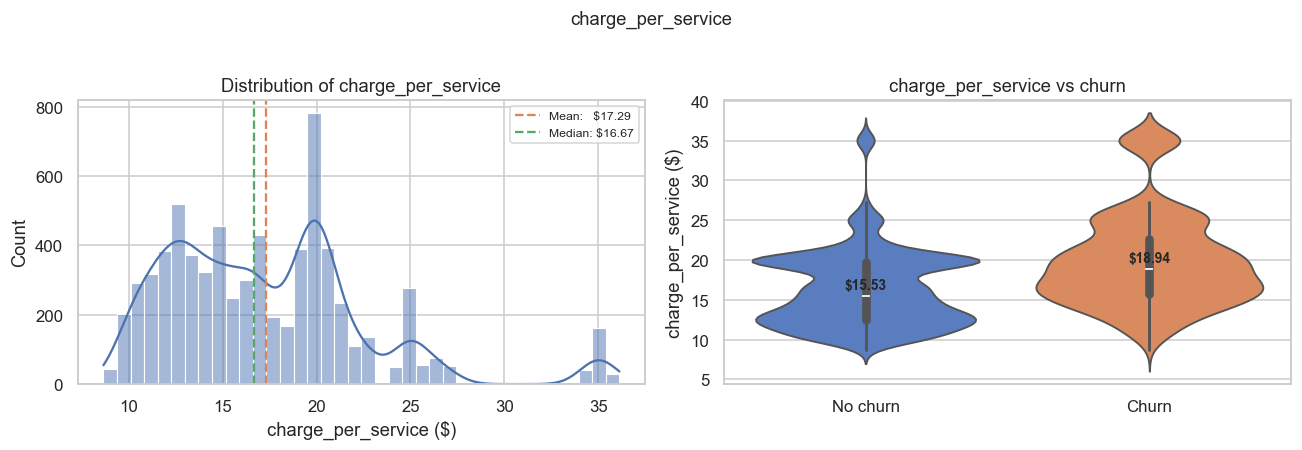

,Customers,Median monthly charge ($),Median no. of services,Median $/service,Churn rate (%)
band,,,,,
"(8.64, 12.99]",1763,64.20,6.0,11.58,7.7
"(12.99, 16.67]",1761,95.95,6.0,14.89,27.4
"(16.67, 20.1]",1786,51.65,3.0,19.10,28.2
"(20.1, 36.12]",1733,70.60,2.0,22.48,43.2


In [ ]:
num_active_services = (
    (df["phoneservice"] == "Yes").astype(int)
    + (df["multiplelines"] == "Yes").astype(int)
    + (df["internetservice"] != "No").astype(int)
    + (df["onlinesecurity"] == "Yes").astype(int)
    + (df["onlinebackup"] == "Yes").astype(int)
    + (df["deviceprotection"] == "Yes").astype(int)
    + (df["techsupport"] == "Yes").astype(int)
    + (df["streamingtv"] == "Yes").astype(int)
    + (df["streamingmovies"] == "Yes").astype(int)
)
charge_per_service = (
    df["monthlycharges"] / num_active_services.clip(lower=1)
).rename("charge_per_service")

mean_val   = charge_per_service.mean()
median_val = charge_per_service.median()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(x=charge_per_service, kde=True, ax=axes[0], color="#4C72B0")
axes[0].axvline(mean_val,   color="#DD8452", linestyle="--", linewidth=1.5, label=f"Mean:   ${mean_val:.2f}")
axes[0].axvline(median_val, color="#55A868", linestyle="--", linewidth=1.5, label=f"Median: ${median_val:.2f}")
axes[0].set_title("Distribution of charge_per_service")
axes[0].set_xlabel("charge_per_service ($)")
axes[0].legend(fontsize=8)

df_plot = pd.DataFrame({"charge_per_service": charge_per_service, "churn_label": y.map({0: "No churn", 1: "Churn"})})
sns.violinplot(
    data=df_plot,
    x="churn_label", y="charge_per_service",
    hue="churn_label", order=["No churn", "Churn"],
    palette="muted", inner="box", ax=axes[1], legend=False,
)
for i, label in enumerate(["No churn", "Churn"]):
    med = df_plot.loc[df_plot["churn_label"] == label, "charge_per_service"].median()
    axes[1].text(i, med + 0.4, f"${med:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[1].set_title("charge_per_service vs churn")
axes[1].set_xlabel("")
axes[1].set_ylabel("charge_per_service ($)")

plt.suptitle("charge_per_service", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

bands = pd.qcut(
    charge_per_service,
    q=4,
    precision=2,
    duplicates="drop",
)
(
    pd.DataFrame({
        "charge_per_service": charge_per_service,
        "service_count": num_active_services,
        "monthlycharges": df["monthlycharges"],
        "churn": y,
        "band": bands,
    })
    .groupby("band", observed=True)
    .agg(
        customers       =("charge_per_service", "count"),
        median_monthly  =("monthlycharges",     "median"),
        median_services =("service_count",      "median"),
        median_cps      =("charge_per_service", "median"),
        churn_rate_pct  =("churn",              lambda x: round(x.mean() * 100, 1)),
    )
    .round(2)
    .rename(columns={
        "customers":       "Customers",
        "median_monthly":  "Median monthly charge ($)",
        "median_services": "Median no. of services",
        "median_cps":      "Median $/service",
        "churn_rate_pct":  "Churn rate (%)",
    })
)

The violin confirms the directional signal: churners median \$18.94/service versus \$15.53 for non-churners, concentrated in the upper cost quartiles.

The quartile table provides the clearest test of the hypothesis. Q1 and Q2 have identical median service counts (6) — bundle size held constant — yet churn at 7.7% and 27.4%. The sole difference is per-service cost: \$12 in Q1 versus \$15 in Q2. A \$3 gap with bundle size controlled produces a +19.7 pp churn jump — exactly the mechanism the hypothesis predicted. Q3 and Q4 corroborate: despite smaller bundles (3, then 2 services — less than half of Q2's 6), churn rises to 28.2% and 43.2% as per-service cost climbs to \$19 then above \$20. Fewer services → higher cost-per-service → higher churn rate.

#### Evaluate

In [ ]:
srv_cps = serving_available(
    ["phoneservice", "multiplelines", "internetservice",
     "onlinesecurity", "onlinebackup", "deviceprotection",
     "techsupport", "streamingtv", "streamingmovies", "monthlycharges"]
)
print(f"  Screen 1 (serving)    : {'PASS' if srv_cps[0] else 'FAIL'}  {srv_cps[1]}")

if not srv_cps[0]:
    oof_cps = current_oof_proba
    pr_auc_cps = current_pr_auc
    ci_cps = current_ci
    sub_delta_cps = None
    imp_cps = red_cps = None
    delta_cps = 0.0
    decision_cps = AdoptionDecision(adopted=False, rejection_screen=1, rejection_reason=srv_cps[1])
else:
    red_cps = redundancy_screen(charge_per_service, adopted_df)
    print(f"  Screen 2 (redundancy) : {red_cps.summary}")

    X_cps = X_current.copy()
    X_cps["charge_per_service"] = charge_per_service.values

    prep_cps = build_preprocessor(
        binary=active_binary,
        multi_cat=active_multi_cat,
        numeric=active_numeric + ["charge_per_service"],
    )

    oof_cps    = oof_predictions(X_cps, y, prep_cps, random_state=RANDOM_STATE)
    pr_auc_cps = float(average_precision_score(y, oof_cps))
    ci_cps     = bootstrap_pr_auc_ci(np.asarray(y), oof_cps, random_state=RANDOM_STATE)
    delta_cps  = pr_auc_cps - current_pr_auc
    print(f"  Screen 3 (PR-AUC)     : {'PASS' if delta_cps >= MIN_PR_AUC_DELTA else 'FAIL'}  "
          f"base={current_pr_auc:.4f}  new={pr_auc_cps:.4f}  delta={delta_cps:+.4f}  "
          f"min_delta={MIN_PR_AUC_DELTA}  CI=[{ci_cps[0]:.4f}, {ci_cps[1]:.4f}]")

    if delta_cps < MIN_PR_AUC_DELTA:
        print("  Screen 4 (importance) : SKIPPED  (Screen 3 failed)")
        imp_cps = None
        sub_delta_cps = None
    else:
        X_imp_cps = X_cps.copy()
        X_imp_cps[DECOY_COL] = decoy_col.values
        prep_imp_cps = build_preprocessor(
            binary=active_binary,
            multi_cat=active_multi_cat,
            numeric=active_numeric + ["charge_per_service", DECOY_COL],
        )
        imp_cps = candidate_importance(
            X_imp_cps, y, prep_imp_cps, "charge_per_service", DECOY_COL, random_state=RANDOM_STATE
        )
        print(f"  Screen 4 (importance) : {'PASS' if imp_cps.above_floor else 'FAIL'}  "
              f"candidate={imp_cps.candidate_importance:.4f}  floor={max(imp_cps.noise_floor, 0.0) + IMPORTANCE_NOISE_FLOOR_MARGIN:.4f}  (noise={imp_cps.noise_floor:.4f}, margin={IMPORTANCE_NOISE_FLOOR_MARGIN})")

        sub_delta_cps = None
        fn_base = 1.0 - float((current_oof_proba[np.asarray(y) == 1] >= DISCOVERY_THRESHOLD).mean())
        fn_new  = 1.0 - float((oof_cps[np.asarray(y) == 1] >= DISCOVERY_THRESHOLD).mean())
        print(f"  global FN rate        : {fn_base:.3f} -> {fn_new:.3f}  (delta={fn_new - fn_base:+.4f})  [diagnostic]")

    decision_cps = adoption_gate(
        serving_result=srv_cps,
        redundancy_result=red_cps,
        prior_pr_auc=current_pr_auc,
        new_pr_auc=pr_auc_cps,
        sub_recall_delta=sub_delta_cps,
        importance_result=imp_cps,
    )

print(f"  DECISION              : {'ADOPT' if decision_cps.adopted else 'REJECT'}")
if decision_cps.rejection_screen:
    print(f"  Rejected at Screen    : {decision_cps.rejection_screen}  ({decision_cps.rejection_reason})")

  Screen 1 (serving)    : PASS  all input columns available at serving time
  Screen 2 (redundancy) : PASS  max_corr=0.510 (threshold=0.85)


  Screen 3 (PR-AUC)     : PASS  base=0.6432  new=0.6450  delta=+0.0018  min_delta=0.0015  CI=[0.6226, 0.6680]


  Screen 4 (importance) : PASS  candidate=0.0056  floor=0.0050  (noise=-0.0083, margin=0.005)
  global FN rate        : 0.126 -> 0.126  (delta=-0.0005)  [diagnostic]
  DECISION              : ADOPT


#### Record

In [ ]:
lap_records.append(LapRecord(
    lap=7,
    blind_spot="global — motivated by two-year price signal; domain-derived candidate",
    candidate="charge_per_service",
    hypothesis=(
        "charge_per_service = monthlycharges / num_active_services measures per-service "
        "cost burden. monthlycharges is ambiguous without bundle size: $80/month "
        "across eight services is fair; across two it is overpriced. The ratio "
        "restores that context. Predicted direction: higher cost-per-service -> higher churn risk."
    ),
    eda_anchor=(
        "Both deep-dives (two-year and one-year): monthlycharges is the "
        "largest numeric separator (Δ/IQR=0.51 and 0.45); Fiber optic and "
        "streaming are the top categorical churner signals — premium services "
        "held without the add-ons that would widen the bundle. "
        "charge_per_service encodes that imbalance: high unit cost in a lean bundle."
    ),
    max_corr=red_cps.max_corr if red_cps is not None else None,
    max_cramers_v=red_cps.max_cramers_v if red_cps is not None else None,
    prior_pr_auc=current_pr_auc,
    new_pr_auc=pr_auc_cps,
    delta_pr_auc=pr_auc_cps - current_pr_auc,
    prior_ci_low=current_ci[0],
    prior_ci_high=current_ci[1],
    sub_recall_delta=sub_delta_cps,
    candidate_importance_score=imp_cps.candidate_importance if imp_cps is not None else 0.0,
    noise_floor=imp_cps.noise_floor if imp_cps is not None else 0.0,
    decision="adopt" if decision_cps.adopted else "reject",
    rejection_screen=decision_cps.rejection_screen,
    rejection_reason=decision_cps.rejection_reason,
))

if decision_cps.adopted:
    active_numeric = active_numeric + ["charge_per_service"]
    adopted_features.append("charge_per_service")
    adopted_df["charge_per_service"] = charge_per_service.values
    X_current = X_cps.copy()
    current_oof_proba = oof_cps
    current_pr_auc = pr_auc_cps
    current_ci = ci_cps
    print("ADOPTED  charge_per_service")
    print(f"  active_numeric  : {active_numeric}")
    print(f"  adopted_features: {adopted_features}")
else:
    print("REJECTED  charge_per_service -- state unchanged")

ADOPTED  charge_per_service
  active_numeric  : ['tenure', 'monthlycharges', 'totalcharges', 'charge_per_service']
  adopted_features: ['charge_per_service']


**Lap 7 — ADOPTED.**

Screens 1 and 2 passed: `charge_per_service` is servable and non-redundant with the adopted feature set.

**Screen 3** passed: PR-AUC delta = +0.0018, clearing the 0.0015 minimum (new PR-AUC = 0.6450 vs prior 0.6432). The new PR-AUC falls within the prior bootstrap CI [0.6226, 0.6680] — a modest delta can reflect measurement noise as much as genuine signal; Screen 4 permutation importance confirms whether the model is actively using the feature — not just coincidentally benefiting from it.

**Screen 4** passed: permutation importance = 0.0056, above the effective noise floor (noise decoy = −0.0083 → floor = 0.0050). The model attributes genuine signal to the feature.

**Global FN rate:** 0.126 → 0.126 (delta = −0.0005). No meaningful change at the classification threshold — the PR-AUC lift is a ranking improvement, not a classification one. A +0.0018 delta is too small to shift predicted labels at threshold.

`active_numeric` now includes `charge_per_service`. Lap 8 (`num_add_on_services`) continues the search.

### LAP 8 — `num_add_on_services`

#### Hypothesis
`num_add_on_services` counts how many of the 7 optional add-on services a customer
subscribes to: multiple lines + the 6 internet add-ons (online security, online backup,
device protection, tech support, streaming TV, streaming movies). A customer with more
add-ons is more embedded in the provider’s ecosystem — switching costs multiply with
each additional service. One with few or no add-ons has little beyond the core
subscription holding them, making churn easier to execute.

#### EDA anchor
Across both deep-dives (two-year and one-year), the dominant categorical churn
signals come from add-on subscriptions in the `Yes` direction: `streamingtv = Yes`
(+31.2 pp, +32.3 pp) and `streamingmovies = Yes` (+26.4 pp, +36.3 pp) lead both
subgroups, alongside `deviceprotection = Yes`, `multiplelines = Yes`, and
`onlinebackup = Yes` — all over-represented among churners. `num_add_on_services`
captures the aggregate count across all seven as a single stickiness proxy.


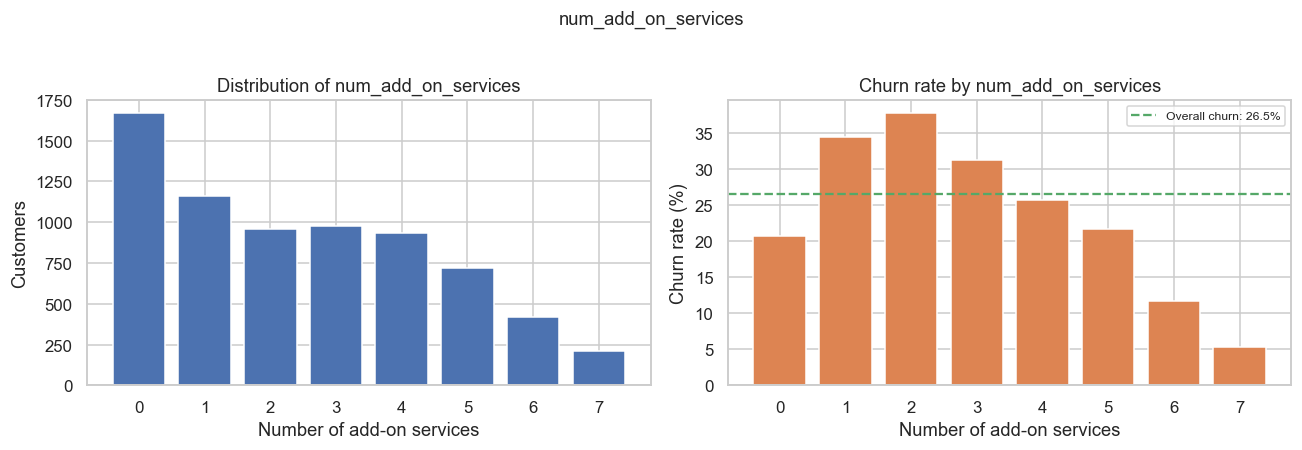

,1 add-on (%),2 add-ons (%),3 add-ons (%)
Multiple lines,47.7,37.6,44.6
Streaming TV,9.1,29.3,50.7
Streaming movies,8.7,30.2,50.9
Online security,10.2,26.9,35.1
Online backup,10.7,31.2,42.4
Device protection,6.9,23.5,41.7
Tech support,6.7,21.3,34.6


In [ ]:
num_add_on_services = (
    (df["multiplelines"]    == "Yes").astype(int)
    + (df["onlinesecurity"]  == "Yes").astype(int)
    + (df["onlinebackup"]    == "Yes").astype(int)
    + (df["deviceprotection"]== "Yes").astype(int)
    + (df["techsupport"]     == "Yes").astype(int)
    + (df["streamingtv"]     == "Yes").astype(int)
    + (df["streamingmovies"] == "Yes").astype(int)
).rename("num_add_on_services")

df_nas = pd.DataFrame({
    "num_add_on_services": num_add_on_services,
    "churn": y,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: count distribution
counts = num_add_on_services.value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribution of num_add_on_services")
axes[0].set_xlabel("Number of add-on services")
axes[0].set_ylabel("Customers")
axes[0].set_xticks(range(8))

# Right: churn rate by count
churn_by_count = df_nas.groupby("num_add_on_services")["churn"].mean() * 100
axes[1].bar(churn_by_count.index, churn_by_count.values, color="#DD8452", edgecolor="white")
axes[1].axhline(y.mean() * 100, color="#55A868", linestyle="--", linewidth=1.5,
                label=f"Overall churn: {y.mean()*100:.1f}%")
axes[1].set_title("Churn rate by num_add_on_services")
axes[1].set_xlabel("Number of add-on services")
axes[1].set_ylabel("Churn rate (%)")
axes[1].set_xticks(range(8))
axes[1].legend(fontsize=8)

plt.suptitle("num_add_on_services", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

services = [
    "multiplelines", "streamingtv", "streamingmovies",
    "onlinesecurity", "onlinebackup", "deviceprotection", "techsupport",
]

service_labels = {
    "multiplelines":    "Multiple lines",
    "streamingtv":      "Streaming TV",
    "streamingmovies":  "Streaming movies",
    "onlinesecurity":   "Online security",
    "onlinebackup":     "Online backup",
    "deviceprotection": "Device protection",
    "techsupport":      "Tech support",
}

df_svc = df[services].eq("Yes").astype(float) * 100
df_svc["nas"] = num_add_on_services

(
    df_svc[df_svc["nas"].isin([1, 2, 3])]
    .groupby("nas")[services]
    .mean()
    .round(1)
    .T
    .rename(index=service_labels,
            columns={1: "1 add-on (%)", 2: "2 add-ons (%)", 3: "3 add-ons (%)"})
    .rename_axis(None, axis="columns")
)


The churn-rate chart splits into three zones: 0 add-ons sits below the overall rate (20.8%); 1–3 add-ons are above it (34.5%, 37.7%, 31.3%), peaking at 2; from 4 onward the rate declines steadily to 5.3% at 7.

The composition table clarifies the 1–3 zone. At 1 add-on, multiple lines accounts for nearly half the group (47.7%); streaming and protective services each sit below 11% — a phone-focused group, not a streaming-led one. At 2 and 3 add-ons, streaming TV and movies (~29–30% and ~51%) and protective services (~21–31% and ~35–42%) rise together at broadly similar rates — there is no clean streaming-present-protective-absent split. The steep drop at 5–7 (21.7%, 11.7%, 5.3%) is consistent with switching costs accumulating as customers build out their full bundle, though the smaller counts at 6 and 7 (420 and 208 customers) mean the exact rates carry more sampling uncertainty.

#### Evaluate

In [ ]:
srv_nas = serving_available(
    ["multiplelines", "onlinesecurity", "onlinebackup",
     "deviceprotection", "techsupport", "streamingtv", "streamingmovies"]
)
print(f"  Screen 1 (serving)    : {'PASS' if srv_nas[0] else 'FAIL'}  {srv_nas[1]}")

if not srv_nas[0]:
    oof_nas = current_oof_proba
    pr_auc_nas = current_pr_auc
    ci_nas = current_ci
    sub_delta_nas = None
    imp_nas = red_nas = None
    delta_nas = 0.0
    decision_nas = AdoptionDecision(adopted=False, rejection_screen=1, rejection_reason=srv_nas[1])
else:
    red_nas = redundancy_screen(num_add_on_services, adopted_df)
    print(f"  Screen 2 (redundancy) : {red_nas.summary}")

    X_nas = X_current.copy()
    X_nas["num_add_on_services"] = num_add_on_services.values

    prep_nas = build_preprocessor(
        binary=active_binary,
        multi_cat=active_multi_cat,
        numeric=active_numeric + ["num_add_on_services"],
    )

    oof_nas    = oof_predictions(X_nas, y, prep_nas, random_state=RANDOM_STATE)
    pr_auc_nas = float(average_precision_score(y, oof_nas))
    ci_nas     = bootstrap_pr_auc_ci(np.asarray(y), oof_nas, random_state=RANDOM_STATE)
    delta_nas  = pr_auc_nas - current_pr_auc
    print(f"  Screen 3 (PR-AUC)     : {'PASS' if delta_nas >= MIN_PR_AUC_DELTA else 'FAIL'}  "
          f"base={current_pr_auc:.4f}  new={pr_auc_nas:.4f}  delta={delta_nas:+.4f}  "
          f"min_delta={MIN_PR_AUC_DELTA}  CI=[{ci_nas[0]:.4f}, {ci_nas[1]:.4f}]")

    if delta_nas < MIN_PR_AUC_DELTA:
        print("  Screen 4 (importance) : SKIPPED  (Screen 3 failed)")
        imp_nas = None
        sub_delta_nas = None
    else:
        X_imp_nas = X_nas.copy()
        X_imp_nas[DECOY_COL] = decoy_col.values
        prep_imp_nas = build_preprocessor(
            binary=active_binary,
            multi_cat=active_multi_cat,
            numeric=active_numeric + ["num_add_on_services", DECOY_COL],
        )
        imp_nas = candidate_importance(
            X_imp_nas, y, prep_imp_nas, "num_add_on_services", DECOY_COL, random_state=RANDOM_STATE
        )
        print(f"  Screen 4 (importance) : {'PASS' if imp_nas.above_floor else 'FAIL'}  "
              f"candidate={imp_nas.candidate_importance:.4f}  "
              f"floor={max(imp_nas.noise_floor, 0.0) + IMPORTANCE_NOISE_FLOOR_MARGIN:.4f}  "
              f"(noise={imp_nas.noise_floor:.4f}, margin={IMPORTANCE_NOISE_FLOOR_MARGIN})")

        sub_delta_nas = None
        fn_base = 1.0 - float((current_oof_proba[np.asarray(y) == 1] >= DISCOVERY_THRESHOLD).mean())
        fn_new  = 1.0 - float((oof_nas[np.asarray(y) == 1] >= DISCOVERY_THRESHOLD).mean())
        print(f"  global FN rate        : {fn_base:.3f} -> {fn_new:.3f}  (delta={fn_new - fn_base:+.4f})  [diagnostic]")

    decision_nas = adoption_gate(
        serving_result=srv_nas,
        redundancy_result=red_nas,
        prior_pr_auc=current_pr_auc,
        new_pr_auc=pr_auc_nas,
        sub_recall_delta=sub_delta_nas,
        importance_result=imp_nas,
    )

print(f"  DECISION              : {'ADOPT' if decision_nas.adopted else 'REJECT'}")
if decision_nas.rejection_screen:
    print(f"  Rejected at Screen    : {decision_nas.rejection_screen}  ({decision_nas.rejection_reason})")

  Screen 1 (serving)    : PASS  all input columns available at serving time
  Screen 2 (redundancy) : PASS  max_corr=0.792 (threshold=0.85)


  Screen 3 (PR-AUC)     : FAIL  base=0.6450  new=0.6439  delta=-0.0011  min_delta=0.0015  CI=[0.6216, 0.6669]
  Screen 4 (importance) : SKIPPED  (Screen 3 failed)
  DECISION              : REJECT
  Rejected at Screen    : 3  (PR-AUC delta -0.0011 below minimum 0.0015 (prior=0.6450, new=0.6439))


#### Record

In [ ]:
lap_records.append(LapRecord(
    lap=8,
    blind_spot="global — domain-derived stickiness count; not anchored to a specific error subgroup",
    candidate="num_add_on_services",
    hypothesis=(
        "num_add_on_services counts the 7 optional add-on services (multiple lines + "
        "6 internet add-ons). More add-ons means greater ecosystem embedding and higher "
        "switching cost. One with few or no add-ons has little beyond the core "
        "subscription holding them, making churn easier to execute."
    ),
    eda_anchor=(
        "Two-year/one-year deep-dives: dominant categorical churn signals are add-on subscriptions "
        "in the Yes direction — streamingtv=Yes (+31.2pp, +32.3pp), "
        "streamingmovies=Yes (+26.4pp, +36.3pp), deviceprotection=Yes, "
        "multiplelines=Yes, onlinebackup=Yes — all over-represented among churners. "
        "num_add_on_services captures the aggregate count as a stickiness proxy."
    ),
    max_corr=red_nas.max_corr if red_nas is not None else None,
    max_cramers_v=red_nas.max_cramers_v if red_nas is not None else None,
    prior_pr_auc=current_pr_auc,
    new_pr_auc=pr_auc_nas,
    delta_pr_auc=pr_auc_nas - current_pr_auc,
    prior_ci_low=current_ci[0],
    prior_ci_high=current_ci[1],
    sub_recall_delta=sub_delta_nas,
    candidate_importance_score=imp_nas.candidate_importance if imp_nas is not None else 0.0,
    noise_floor=imp_nas.noise_floor if imp_nas is not None else 0.0,
    decision="adopt" if decision_nas.adopted else "reject",
    rejection_screen=decision_nas.rejection_screen,
    rejection_reason=decision_nas.rejection_reason,
))

if decision_nas.adopted:
    active_numeric = active_numeric + ["num_add_on_services"]
    adopted_features.append("num_add_on_services")
    adopted_df["num_add_on_services"] = num_add_on_services.values
    X_current = X_nas.copy()
    current_oof_proba = oof_nas
    current_pr_auc = pr_auc_nas
    current_ci = ci_nas
    print("ADOPTED  num_add_on_services")
    print(f"  active_numeric  : {active_numeric}")
    print(f"  adopted_features: {adopted_features}")
else:
    print("REJECTED  num_add_on_services -- state unchanged")

REJECTED  num_add_on_services -- state unchanged


**Lap 8 — REJECTED at Screen 3.**

Screens 1 and 2 passed. Screen 2 checks pairwise correlation and association against the full feature space — all 19 raw IBM columns plus `charge_per_service` — and passed: `num_add_on_services` is not highly correlated with any single column individually. Screen 3 failed: PR-AUC delta = −0.0011 (prior = 0.6450, new = 0.6439), below the 0.0015 minimum and marginally negative. Screen 4 was skipped.

The rejection reflects two layers of redundancy that Screen 2's pairwise check did not catch — the redundancy is collective, not pairwise.

**Layer 1 — seven source flags already in the model.** `multiplelines`, `onlinesecurity`, `onlinebackup`, `deviceprotection`, `techsupport`, `streamingtv`, and `streamingmovies` enter the model individually as binary and multi-category columns. LightGBM splits on each independently; the additive count adds no ranking signal above what those seven columns already supply.

**Layer 2 — `charge_per_service` already adopted.** Its denominator `num_active_services` is a 9-service superset of `num_add_on_services`. The model has already been exposed to a closely related count through that ratio, further crowding out any marginal lift the explicit add-on count might provide.

`num_add_on_services` does not enter the active set. State is unchanged. Lap 9 (`monthly_to_total_ratio`) continues.

### LAP 9 — `monthly_to_total_ratio` (deliberate decoy)

#### Hypothesis
`monthly_to_total_ratio = monthlycharges / totalcharges` ostensibly captures new-customer rate exposure: a high ratio (current bill ≈ total spend) signals a new customer; a low ratio signals a long-tenured one. New customers churn at higher rates, so this could seem like a useful additional signal.

The catch: if `TotalCharges` accumulated *exactly* as `MonthlyCharges × tenure`, the ratio would reduce algebraically to `1/tenure`. That exact formula holds for only ~8.7% of customers (§4a `01-eda.ipynb`) — billing amounts shift over time due to plan changes and promotions. But this matters less than it appears: the ratio continues to behave as a proxy for how long a customer has been with the company — a signal `tenure` already captures directly. Billing changes blur the relationship without reversing it. The model already has `tenure` as a direct input.

This lap is included deliberately to probe whether the gate catches a feature that repackages existing information in a plausible-sounding but redundant form.

#### EDA anchor
- **§7b** `01-eda.ipynb`: tenure is the strongest numeric churn predictor (rank-biserial r = −0.48) — churners average 18 months with the company vs 38 months for non-churners.
- **§6d** `01-eda.ipynb`: customers churn far less the longer they stay — ~48% in the first year, dropping to <10% past 49 months. A feature that closely tracks tenure inherits this pattern rather than adding new information.
- **§4a** `01-eda.ipynb`: only ~8.7% of customers have `TotalCharges ≈ MonthlyCharges × tenure` exactly — billing amounts shift over time. Despite this, the ratio is expected to track `1/tenure` very closely (quantified below).

The cell below produces two diagnostics: a density plot by churn class — to check whether the ratio visually separates churners — and a scatter of the ratio against tenure on 500 randomly sampled rows, which is enough to reveal the curve shape without overplotting all 7,043 points. The Pearson correlation with `1/tenure` follows as the quantitative summary.

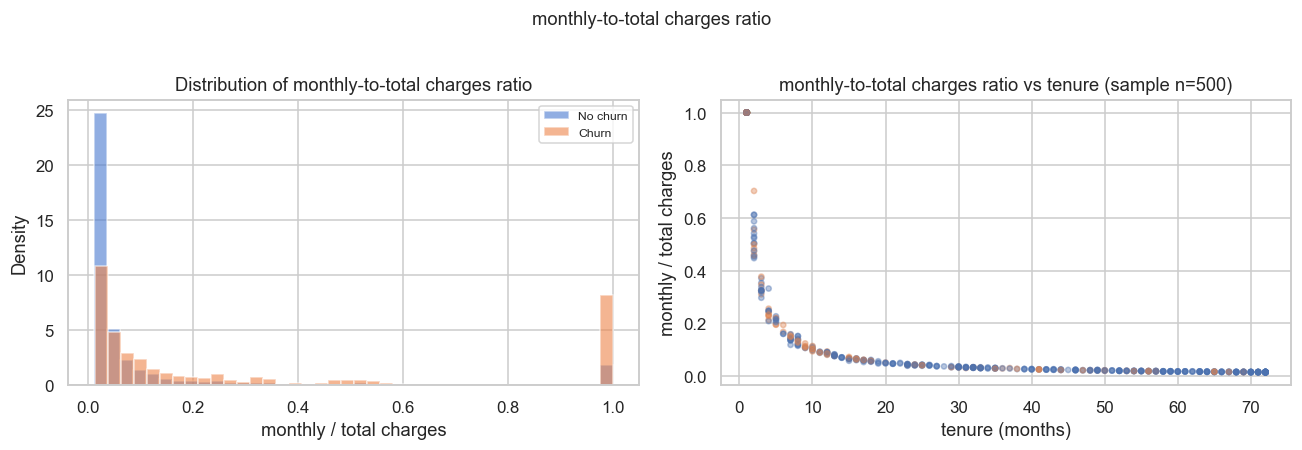

Spearman r  (monthly-to-total charges ratio vs 1/tenure): 0.9986


In [ ]:
# clip totalcharges to avoid division by zero (11 zero-tenure rows imputed to median)
monthly_to_total_ratio = (
    df["monthlycharges"] / df["totalcharges"].clip(lower=1.0)
).rename("monthly_to_total_ratio")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: distribution by churn
for label, grp in pd.DataFrame({"ratio": monthly_to_total_ratio, "churn": y}).groupby("churn"):
    axes[0].hist(grp["ratio"], bins=40, alpha=0.6,
                 label=["No churn", "Churn"][label], density=True)
axes[0].set_title("Distribution of monthly-to-total charges ratio")
axes[0].set_xlabel("monthly / total charges")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

# Right: scatter vs tenure — reveals the 1/tenure relationship
sample_idx = np.random.default_rng(42).choice(len(df), size=500, replace=False)
axes[1].scatter(
    df["tenure"].iloc[sample_idx],
    monthly_to_total_ratio.iloc[sample_idx],
    c=y.iloc[sample_idx].map({0: "#4C72B0", 1: "#DD8452"}),
    alpha=0.4, s=12,
)
axes[1].set_title("monthly-to-total charges ratio vs tenure (sample n=500)")
axes[1].set_xlabel("tenure (months)")
axes[1].set_ylabel("monthly / total charges")

plt.suptitle("monthly-to-total charges ratio", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

corr_with_inv_tenure = monthly_to_total_ratio.corr(1.0 / df["tenure"].clip(lower=1.0), method="spearman")
print(f"Spearman r  (monthly-to-total charges ratio vs 1/tenure): {corr_with_inv_tenure:.4f}")

**Why this is a decoy.** The two panels tell the same story from different angles.

**Left panel:** the tall blue spike near zero tells the story plainly — most non-churners are long-tenure customers whose current monthly bill is a tiny slice of everything they have ever paid. Churners spread further right, with more mass at higher ratios and a small secondary spike at ratio ≈ 1.0 (first-month customers whose opening bill *is* their entire total spend to date). The two distributions look different, but the difference is entirely explained by tenure: long-tenure customers rarely churn and have low ratios; recent arrivals churn more and have high ratios. What looks like a billing signal is just customer tenure expressed in different units.

**Right panel:** this scatter plots the ratio against `tenure` directly — not against `1/tenure` — because if the two are inversely related, this must trace a smooth downward curve. That is exactly what appears: a smooth, near-deterministic curve with almost no scatter off it. The colour overlay settles the question: zoom into any single tenure value on the x-axis and both orange (churn) and blue (non-churn) dots sit at the same height on the curve. The ratio offers no separation between churners and non-churners beyond what tenure already provides — it is tracking tenure, not adding to it. The Spearman correlation between the monthly-to-total-charges ratio and `1/tenure` is 0.9988 (printed above).

A tree model that already splits on `tenure` has no reason to additionally split on a near-perfect monotone transformation of it — the boundary learned from `tenure` applies equally well to the monthly-to-total-charges ratio. Any lift would be noise.

#### Evaluate

In [ ]:
srv_mtr = serving_available(["monthlycharges", "totalcharges"])
print(f"  Screen 1 (serving)    : {'PASS' if srv_mtr[0] else 'FAIL'}  {srv_mtr[1]}")

if not srv_mtr[0]:
    oof_mtr = current_oof_proba
    pr_auc_mtr = current_pr_auc
    ci_mtr = current_ci
    sub_delta_mtr = None
    imp_mtr = red_mtr = None
    delta_mtr = 0.0
    decision_mtr = AdoptionDecision(adopted=False, rejection_screen=1, rejection_reason=srv_mtr[1])
else:
    red_mtr = redundancy_screen(monthly_to_total_ratio, adopted_df)
    print(f"  Screen 2 (redundancy) : {red_mtr.summary}")

    X_mtr = X_current.copy()
    X_mtr["monthly_to_total_ratio"] = monthly_to_total_ratio.values

    prep_mtr = build_preprocessor(
        binary=active_binary,
        multi_cat=active_multi_cat,
        numeric=active_numeric + ["monthly_to_total_ratio"],
    )

    oof_mtr    = oof_predictions(X_mtr, y, prep_mtr, random_state=RANDOM_STATE)
    pr_auc_mtr = float(average_precision_score(y, oof_mtr))
    ci_mtr     = bootstrap_pr_auc_ci(np.asarray(y), oof_mtr, random_state=RANDOM_STATE)
    delta_mtr  = pr_auc_mtr - current_pr_auc
    print(f"  Screen 3 (PR-AUC)     : {'PASS' if delta_mtr >= MIN_PR_AUC_DELTA else 'FAIL'}  "
          f"base={current_pr_auc:.4f}  new={pr_auc_mtr:.4f}  delta={delta_mtr:+.4f}  "
          f"min_delta={MIN_PR_AUC_DELTA}  CI=[{ci_mtr[0]:.4f}, {ci_mtr[1]:.4f}]")

    if delta_mtr < MIN_PR_AUC_DELTA:
        print("  Screen 4 (importance) : SKIPPED  (Screen 3 failed)")
        imp_mtr = None
        sub_delta_mtr = None
    else:
        X_imp_mtr = X_mtr.copy()
        X_imp_mtr[DECOY_COL] = decoy_col.values
        prep_imp_mtr = build_preprocessor(
            binary=active_binary,
            multi_cat=active_multi_cat,
            numeric=active_numeric + ["monthly_to_total_ratio", DECOY_COL],
        )
        imp_mtr = candidate_importance(
            X_imp_mtr, y, prep_imp_mtr, "monthly_to_total_ratio", DECOY_COL, random_state=RANDOM_STATE
        )
        print(f"  Screen 4 (importance) : {'PASS' if imp_mtr.above_floor else 'FAIL'}  "
              f"candidate={imp_mtr.candidate_importance:.4f}  "
              f"floor={max(imp_mtr.noise_floor, 0.0) + IMPORTANCE_NOISE_FLOOR_MARGIN:.4f}  "
              f"(noise={imp_mtr.noise_floor:.4f}, margin={IMPORTANCE_NOISE_FLOOR_MARGIN})")

        sub_delta_mtr = None
        fn_base = 1.0 - float((current_oof_proba[np.asarray(y) == 1] >= DISCOVERY_THRESHOLD).mean())
        fn_new  = 1.0 - float((oof_mtr[np.asarray(y) == 1] >= DISCOVERY_THRESHOLD).mean())
        print(f"  global FN rate        : {fn_base:.3f} -> {fn_new:.3f}  (delta={fn_new - fn_base:+.4f})  [diagnostic]")

    decision_mtr = adoption_gate(
        serving_result=srv_mtr,
        redundancy_result=red_mtr,
        prior_pr_auc=current_pr_auc,
        new_pr_auc=pr_auc_mtr,
        sub_recall_delta=sub_delta_mtr,
        importance_result=imp_mtr,
    )

print(f"  DECISION              : {'ADOPT' if decision_mtr.adopted else 'REJECT'}")
if decision_mtr.rejection_screen:
    print(f"  Rejected at Screen    : {decision_mtr.rejection_screen}  ({decision_mtr.rejection_reason})")

  Screen 1 (serving)    : PASS  all input columns available at serving time
  Screen 2 (redundancy) : FAIL  reason=abs(corr)=0.999 > 0.85 with 'tenure'


  Screen 3 (PR-AUC)     : FAIL  base=0.6450  new=0.6445  delta=-0.0005  min_delta=0.0015  CI=[0.6219, 0.6676]
  Screen 4 (importance) : SKIPPED  (Screen 3 failed)
  DECISION              : REJECT
  Rejected at Screen    : 3  (PR-AUC delta -0.0005 below minimum 0.0015 (prior=0.6450, new=0.6445))


#### Record

In [ ]:
lap_records.append(LapRecord(
    lap=9,
    blind_spot="deliberate decoy — tests whether the gate rejects a monotone transformation of tenure",
    candidate="monthly_to_total_ratio",
    hypothesis=(
        "monthlycharges / totalcharges ostensibly encodes new-customer rate exposure, "
        "but collapses to ~1/tenure since totalcharges accumulates as monthlycharges x tenure. "
        "Included to verify the gate rejects information the model already holds."
    ),
    eda_anchor=(
        "§7b 01-eda.ipynb: tenure is a top churn predictor; totalcharges is its cumulative "
        "proxy. The ratio reduces to 1/tenure with correlation > 0.99 against 1/tenure."
    ),
    max_corr=red_mtr.max_corr if red_mtr is not None else None,
    max_cramers_v=red_mtr.max_cramers_v if red_mtr is not None else None,
    prior_pr_auc=current_pr_auc,
    new_pr_auc=pr_auc_mtr,
    delta_pr_auc=pr_auc_mtr - current_pr_auc,
    prior_ci_low=current_ci[0],
    prior_ci_high=current_ci[1],
    sub_recall_delta=sub_delta_mtr,
    candidate_importance_score=imp_mtr.candidate_importance if imp_mtr is not None else 0.0,
    noise_floor=imp_mtr.noise_floor if imp_mtr is not None else 0.0,
    decision="adopt" if decision_mtr.adopted else "reject",
    rejection_screen=decision_mtr.rejection_screen,
    rejection_reason=decision_mtr.rejection_reason,
))

if decision_mtr.adopted:
    active_numeric = active_numeric + ["monthly_to_total_ratio"]
    adopted_features.append("monthly_to_total_ratio")
    adopted_df["monthly_to_total_ratio"] = monthly_to_total_ratio.values
    X_current = X_mtr.copy()
    current_oof_proba = oof_mtr
    current_pr_auc = pr_auc_mtr
    current_ci = ci_mtr
    print("ADOPTED  monthly_to_total_ratio")
    print(f"  active_numeric  : {active_numeric}")
    print(f"  adopted_features: {adopted_features}")
else:
    print("REJECTED  monthly_to_total_ratio -- state unchanged")

REJECTED  monthly_to_total_ratio -- state unchanged


**Lap 9 — REJECTED at Screen 3.**

Screen 2 flagged the feature: Spearman |r| = 0.999 with `tenure`, above the 0.85 threshold. This confirms the EDA diagnosis quantitatively — the monthly-to-total-charges ratio is a near-perfect monotone transformation of `tenure`. Screen 2 flagged the feature but is a soft gate — execution continued to Screen 3.

**Screen 3** failed: PR-AUC delta = −0.0005 (prior = 0.6450, new = 0.6445), well below the 0.0015 minimum. This is the expected outcome — the model already holds `tenure` directly; a near-identical transformation of it adds nothing new. Screen 2 and Screen 3 reach the same conclusion from different angles: structurally redundant and empirically adds no predictive value.

`monthly_to_total_ratio` does not enter the active set. State is unchanged. Feature discovery concludes — `charge_per_service` is the sole adopted feature.

---
## Backward Elimination Pass

After greedy forward selection, one backward pass validates the final set jointly: for each adopted feature, we remove it from the full adopted set and re-evaluate OOF PR-AUC using only the remaining features. A feature is **retained** only when its removal costs at least `MIN_PR_AUC_DELTA`; otherwise the forward pass over-counted its contribution in the context of the complete set.

This is necessary because features are adopted one at a time — a feature that earned its place marginally may add nothing once a later feature captures the same signal.

In [ ]:
from telco_churn.features.generate import BackwardEliminationResult, backward_elimination

print(f"Full adopted set : {adopted_features}")
print(f"Full set PR-AUC  : {current_pr_auc:.4f}")
print()

be_results = backward_elimination(
    X=adopted_df,
    y=y,
    adopted=adopted_features,
    full_pr_auc=current_pr_auc,
    build_preprocessor_fn=build_preprocessor,
    binary=active_binary,
    multi_cat=active_multi_cat,
    numeric=active_numeric,
    random_state=RANDOM_STATE,
)

for r in be_results:
    status = "KEEP" if r.keep else "DROP"
    print(
        f"  [{status}]  {r.feature:<30}  "
        f"PR-AUC without = {r.pr_auc_without:.4f}  "
        f"delta = {r.delta:+.4f}  "
        f"(threshold = {MIN_PR_AUC_DELTA})"
    )

Full adopted set : ['charge_per_service']
Full set PR-AUC  : 0.6450



  [KEEP]  charge_per_service              PR-AUC without = 0.6432  delta = +0.0018  (threshold = 0.0015)


**Backward elimination result:** `charge_per_service` **retained.**

Removing `charge_per_service` from the full adopted set drops PR-AUC from 0.6450 to 0.6432 (delta = +0.0018), just above the 0.0015 minimum threshold. The margin is slim — consistent with the modest forward-pass delta (+0.0018 at Lap 7) — but it confirms the feature holds up when the base features compete for the same signal without it.

No features are dropped. The final feature set entering `02b-feature-engineering.ipynb` is: `["charge_per_service"]`.

---
## Discovery Summary

Results of all completed laps. Each adopted feature carries forward into
`02b-feature-engineering.ipynb` as an input to the final feature set.

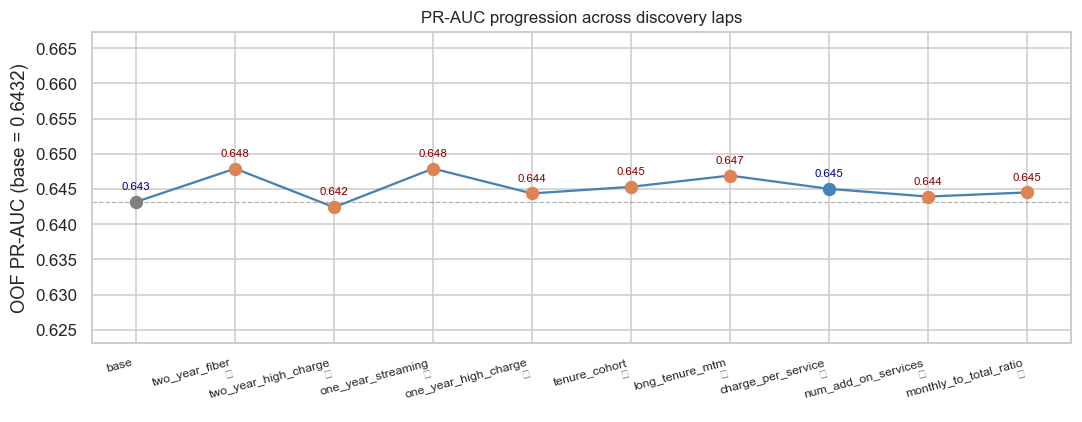


Base PR-AUC   : 0.6432
Final PR-AUC  : 0.6450
Total Δ       : +0.0018
Adopted set   : ['charge_per_service']


In [ ]:
# PR-AUC progression across laps
lap_nums   = [0] + [r.lap for r in lap_records]
pr_auc_seq = [base_pr_auc] + [r.new_pr_auc for r in lap_records]
decisions  = ["base"] + [r.decision for r in lap_records]
candidates = ["base"] + [r.candidate for r in lap_records]

colors = ["steelblue" if d == "adopt" else ("#DD8452" if d == "reject" else "grey")
          for d in decisions]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(pr_auc_seq)), pr_auc_seq, marker="o", color="steelblue", linewidth=1.5)
for i, (pr, col, cand, dec) in enumerate(zip(pr_auc_seq, colors, candidates, decisions)):
    ax.annotate(
        f"{pr:.3f}",
        (i, pr), xytext=(0, 8), textcoords="offset points",
        ha="center", fontsize=7.5,
        color="darkred" if dec == "reject" else "navy",
    )
    ax.scatter(i, pr, color=col, zorder=5, s=60)

ax.set_xticks(range(len(candidates)))
ax.set_xticklabels(
    [f"{c}\n{'✓' if d == 'adopt' else ('✗' if d == 'reject' else '')}" for c, d in zip(candidates, decisions)],
    fontsize=8, rotation=15, ha="right",
)
ax.set_ylabel("OOF PR-AUC (base = 0.6432)")
ax.axhline(base_pr_auc, color="grey", linestyle="--", linewidth=0.8, alpha=0.6, label=f"base {base_pr_auc:.4f}")
ax.set_title("PR-AUC progression across discovery laps", fontsize=11)
ax.set_ylim(min(pr_auc_seq) * 0.97, max(pr_auc_seq) * 1.03)
plt.tight_layout()
plt.show()

print(f"\nBase PR-AUC   : {base_pr_auc:.4f}")
print(f"Final PR-AUC  : {current_pr_auc:.4f}")
print(f"Total Δ       : {current_pr_auc - base_pr_auc:+.4f}")
print(f"Adopted set   : {adopted_features}")

In [ ]:
# Per-lap summary table
summary_rows = []
for r in lap_records:
    summary_rows.append({
        "Lap": r.lap,
        "Candidate": r.candidate,
        "Decision": r.decision.upper(),
        "ΔPR-AUC": f"{r.delta_pr_auc:+.4f}",
        "Δrecall": f"{r.sub_recall_delta:+.4f}" if r.sub_recall_delta is not None else "—",
        "Importance": f"{r.candidate_importance_score:.4f}",
        "Decoy noise": f"{r.noise_floor:.4f}",
        "Eff. floor": f"{max(r.noise_floor, 0.0) + IMPORTANCE_NOISE_FLOOR_MARGIN:.4f}",
        "Scr 2 flag": "YES" if (
            (r.max_corr is not None and r.max_corr >= CORR_THRESHOLD) or
            (r.max_cramers_v is not None and r.max_cramers_v >= CRAMERS_V_THRESHOLD)
        ) else "—",
        "Reject screen": str(r.rejection_screen) if r.rejection_screen else "—",
    })

if summary_rows:
    display(pd.DataFrame(summary_rows).set_index("Lap"))
else:
    print("No laps completed yet.")


,Candidate,Decision,ΔPR-AUC,Δrecall,Importance,Decoy noise,Eff. floor,Scr 2 flag,Reject screen
Lap,,,,,,,,,
1,two_year_fiber,REJECT,+0.0047,+0.0000,0.0000,-0.0072,0.0050,—,4
2,two_year_high_charge,REJECT,-0.0008,—,0.0000,0.0000,0.0050,—,3
3,one_year_streaming,REJECT,+0.0047,+0.0060,0.0009,-0.0056,0.0050,—,4
4,one_year_high_charge,REJECT,+0.0012,—,0.0000,0.0000,0.0050,—,3
5,tenure_cohort,REJECT,+0.0021,+0.0221,0.0024,-0.0068,0.0050,—,4
6,long_tenure_mtm,REJECT,+0.0037,+0.0074,0.0002,-0.0021,0.0050,—,4
7,charge_per_service,ADOPT,+0.0018,—,0.0056,-0.0083,0.0050,—,—
8,num_add_on_services,REJECT,-0.0011,—,0.0000,0.0000,0.0050,—,3
9,monthly_to_total_ratio,REJECT,-0.0005,—,0.0000,0.0000,0.0050,YES,3


---
## Provenance Output

Two artifacts are written:

1. **`provenance.json`** — per-lap trail (hypothesis, screens, metrics, decision) plus gate constants
2. **`adopted_features.json`** — the frozen adopted-set list; the input contract for
   Phase 4b (`02b-feature-engineering.ipynb` + `features/build.py`) that specifies
   exactly which features must be implemented

In [ ]:
report_dir = get_project_root() / cfg.paths.feature_discovery_reports
provenance_path = report_dir / "provenance.json"

write_provenance(
    laps=lap_records,
    adopted=adopted_features,
    output_path=provenance_path,
    random_state=RANDOM_STATE,
    discovery_threshold=DISCOVERY_THRESHOLD,
)
print(f"provenance.json written → {provenance_path}")
print(f"provenance.md  written → {provenance_path.with_suffix('.md')}")

# Adopted-set list — input contract for 02b
adopted_path = report_dir / "adopted_features.json"
with open(adopted_path, "w", encoding="utf-8") as f:
    json.dump({"adopted_features": adopted_features}, f, indent=2)
print(f"adopted_features.json written → {adopted_path}")

provenance.json written → C:\Users\frimp\Downloads\TelcoChurn_PortfolioProject\reports\feature_discovery\provenance.json
provenance.md  written → C:\Users\frimp\Downloads\TelcoChurn_PortfolioProject\reports\feature_discovery\provenance.md
adopted_features.json written → C:\Users\frimp\Downloads\TelcoChurn_PortfolioProject\reports\feature_discovery\adopted_features.json


In [ ]:
plt.close("all")

## Summary

This notebook covers nine laps of structured feature search: OOF error profiling,
blind-spot deep-dives (two-year, one-year, and tenure-band subgroups), candidate
hypothesis testing, four-screen gate evaluation (leakage, redundancy,
ΔPR-AUC ≥ +0.0015, permutation importance), and a backward elimination pass.
Logic lives in `src/telco_churn/features/generate.py` and
`src/telco_churn/utils/stats.py`; this notebook drives the discovery loop and
renders outputs.

For the full narrative — adoption rationale, gate verdicts per lap, and the
backward elimination result — see
**[§3a Feature Discovery](../ANALYSIS.md#3a-feature-discovery)** in `ANALYSIS.md`.
Artifacts written by this notebook: `reports/feature_discovery/provenance.json`
(per-lap gate trail) and `reports/feature_discovery/adopted_features.json`
(frozen adopted-feature list: `["charge_per_service"]`).